**Algonauts 2025 Challenge — Complete Training & Submission Workflow**

This notebook integrates:
- Your MultimodalTRIBE_v2 model + BMORStream front-end
- Starter kit data loading and preprocessing
- Training on a **subset** of data for quick prototyping
- Per-parcel Pearson correlation validation (challenge metric)
- Submission formatting (nested dicts, .npy, .zip for Codabench)

**Steps Overview:**
1. Load precomputed PCA-reduced features (visual, audio, language)
2. Align features and fMRI responses
3. Train MultimodalTRIBE_v2 on a subset (1-2 episodes) with your functions
4. Validate and compute per-parcel correlations
5. Format and prepare submission for Codabench
6. Upload to Codabench for evaluation

**Step 0: Checking environment setup and importing required libraries**

In [1]:
# Importing the required libraries (the most fun part of all the code)

import os
import json
import math
import shutil
import time
from pathlib import Path
import glob
import re
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
import librosa
import ast
import string
import zipfile
from tqdm.notebook import tqdm
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.impute import SimpleImputer
from scipy.stats import pearsonr
from joblib import Parallel, delayed
import cv2
import nibabel as nib
from nilearn import plotting
from nilearn.maskers import NiftiLabelsMasker
import ipywidgets as widgets
from ipywidgets import VBox, Dropdown, Button
from IPython.display import Video, display, clear_output
from moviepy.editor import VideoFileClip
from transformers import BertTokenizer, BertModel
from torchvision.transforms import Compose, Lambda, CenterCrop
from torchvision.models.feature_extraction import create_feature_extractor
from omegaconf import DictConfig, OmegaConf

In [2]:
# Checking GPU availability and properties using PyTorch

import torch

# Check if CUDA is available
cuda_available = torch.cuda.is_available()
print(f"CUDA is available: {cuda_available}")

if cuda_available:
    # Get the number of CUDA devices
    n_cuda_devices = torch.cuda.device_count()
    print(f"Number of CUDA devices: {n_cuda_devices}")
    
    # Print information for each CUDA device
    for i in range(n_cuda_devices):
        device_props = torch.cuda.get_device_properties(i)
        print(f"\nCUDA Device {i}:")
        print(f"  Name: {device_props.name}")
        print(f"  Compute Capability: {device_props.major}.{device_props.minor}")
        print(f"  Total Memory: {device_props.total_memory / 1024**3:.2f} GB")
        
    # Get current device information
    current_device = torch.cuda.current_device()
    print(f"\nCurrent CUDA device: {current_device}")
else:
    print("No CUDA devices found. PyTorch will run on CPU only.")

CUDA is available: True
Number of CUDA devices: 1

CUDA Device 0:
  Name: NVIDIA GeForce RTX 4050 Laptop GPU
  Compute Capability: 8.9
  Total Memory: 6.00 GB

Current CUDA device: 0


In [3]:
# Inspect GPU device properties with PyTorch and nvidia-smi output (if available)
import subprocess
import torch

print('PyTorch CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f'--- GPU {i} ---')
        print('Name:', p.name)
        print('Compute Capability:', f'{p.major}.{p.minor}')
        print('Total memory (GB):', p.total_memory/1024**3)

# Attempt to call nvidia-smi for additional info
try:
    out = subprocess.check_output(['nvidia-smi', '--query-gpu=name,memory.total,driver_version,clocks.sm,temperature.gpu', '--format=csv,noheader,nounits'])
    print('\nnvidia-smi output:')
    print(out.decode('utf-8'))
except Exception as e:
    print('nvidia-smi not available or not found on PATH')

# Quick note: compute capability alone does not give FLOPS without SM count and clock info.
# For rough theoretical peak FLOPS you need: 2 * SMs * cores_per_SM * clock_GHz.
# Use vendor docs or `nvidia-smi -q` / device properties to get SM and clock values.

PyTorch CUDA available: True
--- GPU 0 ---
Name: NVIDIA GeForce RTX 4050 Laptop GPU
Compute Capability: 8.9
Total memory (GB): 5.99658203125

nvidia-smi output:
NVIDIA GeForce RTX 4050 Laptop GPU, 6141, 581.86, 2055, 39



In [4]:
# Checking system configuration
import sys
import subprocess
import torch

def check_nvidia_gpu():
    try:
        # Try to get GPU info using nvidia-smi
        output = subprocess.check_output(['nvidia-smi'], stderr=subprocess.STDOUT)
        return output.decode('utf-8')
    except:
        return "No NVIDIA GPU detected or nvidia-smi not found"

print("System Information:")
print("-" * 50)
print(f"Python Version: {sys.version.split()[0]}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print("\nGPU Information:")
print("-" * 50)
print(check_nvidia_gpu())

System Information:
--------------------------------------------------
Python Version: 3.11.0
PyTorch Version: 2.7.1+cu118
CUDA Available: True
CUDA Version: 11.8

GPU Information:
--------------------------------------------------
Sat Jan 24 17:27:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.86                 Driver Version: 581.86         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

x = torch.rand(3, 3).to(device)  # tensor on GPU
print(x.device)

cuda:0


**Step 2: Data Pre-Processing and Loading**

In [6]:
# Functions to neccessiate alignment of .mkv movies with the .tsv transcripts

def load_transcript(transcript_path):
    """
    Loads a transcript file and returns it as a DataFrame.

    Parameters
    ----------
    transcript_path : str
        Path to the .tsv transcript file.

    """
    df = pd.read_csv(transcript_path, sep='\t')
    return df


def get_movie_info(movie_path):
    """
    Extracts the frame rate (FPS) and total duration of a movie.

    Parameters
    ----------
    movie_path : str
        Path to the .mkv movie file.

    Raises
    ------
    FileNotFoundError
        If the movie file doesn't exist.
    ValueError
        If the video file cannot be opened or has invalid FPS.
    """
    
    # Check if file exists
    if not os.path.exists(movie_path):
        raise FileNotFoundError(f"Movie file not found: {movie_path}")
    
    cap = cv2.VideoCapture(movie_path)
    
    # Check if the video was successfully opened
    if not cap.isOpened():
        raise ValueError(f"Failed to open video file. The file may be corrupted or in an unsupported format: {movie_path}")
    
    fps, frame_count = cap.get(cv2.CAP_PROP_FPS), cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()
    
    # Handle the case where fps is 0 or invalid
    if fps == 0 or fps < 0:
        raise ValueError(f"Invalid FPS detected: {fps}. The video file may be corrupted or in an unsupported format.")
    
    if frame_count <= 0:
        raise ValueError(f"Invalid frame count detected: {frame_count}. The video file may be corrupted.")
    
    video_duration = frame_count / fps
    return fps, video_duration


def split_movie_into_chunks(movie_path, chunk_duration=1.49):
    """
    Divides a video into fixed-duration chunks.

    Parameters
    ----------
    movie_path : str
        Path to the .mkv movie file.
    chunk_duration : float, optional
        Duration of each chunk in seconds (default is 1.49).

    """

    _, video_duration = get_movie_info(movie_path)
    chunks = []
    start_time = 0.0

    # Create chunks for the specified time
    while start_time < video_duration:
        end_time = min(start_time + chunk_duration, video_duration)
        chunks.append((start_time, end_time))
        start_time += chunk_duration
    return chunks

def extract_movie_segment_with_sound(movie_path, start_time, end_time,
    output_path='output_segment.mp4'):
    """
    Extracts a specific segment of a video with sound and saves it.

    Parameters
    ----------
    movie_path : str
        Path to the .mkv movie file.
    start_time : float
        Start time of the segment in seconds.
    end_time : float
        End time of the segment in seconds.
    output_path : str, optional
        Path to save the output segment (default is 'output_segment.mp4').

    """

    # Create movie segment
    movie_segment = VideoFileClip(movie_path).subclip(start_time, end_time)
    print(f"\nWriting movie file from {start_time}s until {end_time}s")

    # Write video file
    movie_segment.write_videofile(output_path, codec="libx264",
        audio_codec="aac", verbose=False, logger=None)
    return output_path


def display_transcript_and_movie(chunk_index, transcript_df, chunks,
    movie_path):
    """
    Displays transcript, movie, onset, and duration for a selected chunk.

    Parameters
    ----------
    chunk_index : int
        Index of the selected chunk.
    transcript_df : DataFrame
        DataFrame containing transcript data.
    chunks : list
        List of (start_time, end_time) tuples for video chunks.
    movie_path : str
        Path to the .mkv movie file.

    """
    # Retrieve the start and end times for the selected chunk
    start_time, end_time = chunks[chunk_index]

    # Get the corresponding transcript row if it exists in the DataFrame
    transcript_chunk = transcript_df.iloc[chunk_index] if chunk_index < len(transcript_df) else None

    # Display the stimulus chunk number
    print(f"\nChunk number: {chunk_index + 1}")

    # Display transcript details if available; otherwise, indicate no dialogue
    if transcript_chunk is not None and pd.notna(transcript_chunk['text_per_tr']):
        print(f"\nText: {transcript_chunk['text_per_tr']}")
        print(f"Words: {transcript_chunk['words_per_tr']}")
        print(f"Onsets: {transcript_chunk.get('onsets_per_tr', 'N/A')}")
        print(f"Durations: {transcript_chunk.get('durations_per_tr', 'N/A')}")
    else:
        print("<No dialogue in this scene>")

    # Extract and display the video segment
    output_movie_path = extract_movie_segment_with_sound(movie_path, start_time,
        end_time)
    display(Video(output_movie_path, embed=True, width=640, height=480))


def create_dropdown_by_text(transcript_df):
    """
    Creates a dropdown widget for selecting chunks by their text.

    Parameters
    ----------
    transcript_df : DataFrame
        DataFrame containing transcript data.

    """

    options = []

    # Iterate over each row in the transcript DataFrame
    for i, row in transcript_df.iterrows():
        if pd.notna(row['text_per_tr']):  # Check if the transcript text is not NaN
            options.append((row['text_per_tr'], i))
        else:
            options.append(("<No dialogue in this scene>", i))
    return widgets.Dropdown(options=options, description='Select scene:')


def interface_display_transcript_and_movie(movie_path, transcript_path):
    """
    Interactive interface to align movie and transcript chunks.

    Parameters
    ----------
    movie_path : str
        Path to the .mkv movie file.
    transcript_path : str
        Path to the transcript file (.tsv).

    """

    # Load the transcript data from the provided path
    transcript_df = load_transcript(transcript_path)

    # Split the video file into chunks of 1.49 seconds
    chunks = split_movie_into_chunks(movie_path)

    # Create a dropdown widget with transcript text as options
    dropdown = create_dropdown_by_text(transcript_df)

    # Create an output widget to display video and transcript details
    output = widgets.Output()

    # Display the dropdown and output widgets
    display(dropdown, output)

    # Define the function to handle dropdown value changes
    def on_chunk_select(change):
        with output:
            output.clear_output()  # Clears previous content
            chunk_index = dropdown.value
            display_transcript_and_movie(chunk_index, transcript_df, chunks,
                movie_path)

    dropdown.observe(on_chunk_select, names='value')

In [15]:
# HRF delay parameter
hrf_delay = 3  #@param {type:"slider", min:0, max:10, step:1}

#root_data_dir = r"C:\Projects\fmri-algonauts-2025\fmri-algonauts-2025 data"

# When using through harddrive 
root_data_dir = r"D:\fmri-algonauts-2025-data"

# Define file paths and dataset name
movie_path = root_data_dir + "/algonauts_2025.competitors/stimuli/movies/"
transcript_path = root_data_dir + "/algonauts_2025.competitors/stimuli/transcripts/"
fmri_file_path = root_data_dir + "/algonauts_2025.competitors/fmri/"

In [16]:
print(movie_path)

D:\fmri-algonauts-2025-data/algonauts_2025.competitors/stimuli/movies/


In [17]:
atlas_path = root_data_dir + "/algonauts_2025.competitors/fmri/sub-01/atlas/sub-01_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz"
dataset_name = "ses-003_task-s01e01a"

In [ ]:
# Align the .mkv movies and .tsv language transcripts
# Ensure movie_path and transcript_path are files (if directories, pick the first of each type)

# Handle movie_path
movie_p = Path(movie_path)
if movie_p.is_dir():
	mkv_files = sorted(movie_p.rglob('*.mkv'))
	if not mkv_files:
		raise FileNotFoundError(f"No .mkv movie files found under directory: {movie_path}")
	chosen_movie = str(mkv_files[0])
	print(f"Using movie file: {chosen_movie}")
else:
	chosen_movie = str(movie_p)

# Handle transcript_path
transcript_p = Path(transcript_path)
if transcript_p.is_dir():
	tsv_files = sorted(transcript_p.rglob('*.tsv'))
	if not tsv_files:
		raise FileNotFoundError(f"No .tsv transcript files found under directory: {transcript_path}")
	chosen_transcript = str(tsv_files[0])
	print(f"Using transcript file: {chosen_transcript}")
else:
	if not transcript_p.exists():
		raise FileNotFoundError(f"Transcript file not found: {transcript_path}")
	if not os.access(transcript_p, os.R_OK):
		raise PermissionError(f"Cannot read transcript file: {transcript_path}")
	chosen_transcript = str(transcript_p)

# Call the interface function with the resolved file paths
interface_display_transcript_and_movie(chosen_movie, chosen_transcript)

FileNotFoundError: No .mkv movie files found under directory: D:\fmri-algonauts-2025-data/algonauts_2025.competitors/stimuli/movies/

In [ ]:
# Brain visualization functions with fmri data mapping to brain regions

def plot_fmri_on_brain(chunk_index, fmri_file_path, atlas_path, dataset_name,
    hrf_delay):
    """
    Map fMRI responses to brain parcels and plot it on a glass brain.

    Parameters
    ----------
    chunk_index : pandas.Series
        The selected chunk from the transcript, used to determine the fMRI
        sample.
    fmri_file_path : str
        Path to the HDF5 file containing fMRI data.
    atlas_path : str
        Path to the atlas NIfTI file.
    dataset_name : str
        Name of the dataset inside the HDF5 file.
    hrf_delay : int
        fMRI detects the BOLD (Blood Oxygen Level Dependent) response, a signal
        that reflects changes in blood oxygenation levels in response to
        activity in the brain. Blood flow increases to a given brain region in
        response to its activity. This vascular response, which follows the
        hemodynamic response function (HRF), takes time. Typically, the HRF
        peaks around 5–6 seconds after a neural event: this delay reflects the
        time needed for blood oxygenation changes to propagate and for the fMRI
        signal to capture them. Therefore, this parameter introduces a delay
        between stimulus chunks and fMRI samples for a better correspondence
        between input stimuli and the brain response. For example, with a
        hrf_delay of 3, if the stimulus chunk of interest is 17, the
        corresponding fMRI sample will be 20.

    """

    print(f"\nLoading fMRI file: {fmri_file_path}")

    # Load the atlas image
    atlas_img = nib.load(atlas_path)
    atlas_data = atlas_img.get_fdata()

    # Open the fMRI reeponses file, and extract the specific dataset
    with h5py.File(fmri_file_path, 'r') as f:
        print(f"Opening fMRI dataset: {dataset_name}")
        fmri_data = f[dataset_name][()]
        print(f"fMRI dataset shape: {fmri_data.shape}")

    # Extract the corresponding sample from the fMRI responses based on the
    # selected transcript chunk, and on the hrf_delay
    if (chunk_index + hrf_delay) > len(fmri_data):
        selected_sample = len(fmri_data)
    else:
        selected_sample = chunk_index + hrf_delay
    fmri_sample_data = fmri_data[selected_sample]
    print(f"Extracting fMRI sample {selected_sample+1}.")

    # Map fMRI sample values to the brain parcels in the atlas
    output_data = np.zeros_like(atlas_data)
    for parcel_index in range(1000):
        output_data[atlas_data == (parcel_index + 1)] = \
            fmri_sample_data[parcel_index]

    # Create the output NIfTI image
    output_img = nib.Nifti1Image(output_data, affine=atlas_img.affine)

    # Plot the glass brain with the mapped fMRI data
    display = plotting.plot_glass_brain(
        output_img,
        display_mode='lyrz',
        cmap='inferno',
        colorbar=True,
        plot_abs=False)
    colorbar = display._cbar
    colorbar.set_label("fMRI activity", rotation=90, labelpad=12, fontsize=12)
    plotting.show()

In [ ]:
# Main interactive interface with brain visualization
def interface_display_transcript_movie_brain(movie_path, transcript_path,
    fmri_file_path, atlas_path, dataset_name, hrf_delay):
    """
    Interactive interface to display movie and transcripts chunks along with
    the fMRI response from the corresponding sample.

    This code uses functions from Section 1.2.3.

    Parameters
    ----------
    movie_path : str
        Path to the .mkv movie file.
    transcript_path : str
        Path to the .tsv transcript file.
    fmri_file_path : str
        Path to the fMRI data file.
    atlas_path : str
        Path to the brain atlas file.
    dataset_name : str
        Name of the dataset to display fMRI data from.
    hrf_delay : int
        fMRI detects the BOLD (Blood Oxygen Level Dependent) response, a signal
        that reflects changes in blood oxygenation levels in response to
        activity in the brain. Blood flow increases to a given brain region in
        response its activity. This vascular response, which follows the
        hemodynamic response function (HRF), takes time. Typically, the HRF
        peaks around 5–6 seconds after a neural event: this delay reflects the
        time needed for blood oxygenation changes to propagate and for the fMRI
        signal to capture them. Therefore, this parameter introduces a delay
        between stimulus chunks and fMRI samples. For example, with a hrf_delay
        of 3, if the stimulus chunk of interest is 17, the corresponding fMRI
        sample will be 20.

    """

    # Load the .tsv transcript data from the provided path
    transcript_df = load_transcript(transcript_path)  # from 1.2.3

    # Split the .mkv movie file into chunks of 1.49 seconds
    chunks = split_movie_into_chunks(movie_path)  # from 1.2.3

    # Create a dropdown widget with transcript text as options
    dropdown = create_dropdown_by_text(transcript_df)  # from 1.2.3

    # Create an output widget to display video, transcript, and brain
    # visualization
    output = widgets.Output()

    # Define the function to handle dropdown value changes
    def on_chunk_select(change):
        with output:
            output.clear_output()  # Clear the previous output
            chunk_index = dropdown.value

            # Display video chunk and transcript
            display_transcript_and_movie(chunk_index, transcript_df, chunks,
                movie_path)  # from 1.2.3

            # Visualize brain fMRI data
            plot_fmri_on_brain(chunk_index, fmri_file_path, atlas_path,
                dataset_name, hrf_delay)

    dropdown.observe(on_chunk_select, names='value')
    display(dropdown, output)

In [ ]:

# Get the selected transcript row/chunk from the interface
interface_display_transcript_movie_brain(movie_path, transcript_path,
    fmri_file_path, atlas_path, dataset_name, hrf_delay)

**Step 3: Feature Extration of video, audio and text features**

*Video Feature Extraction*

In [ ]:
def get_vision_model(device):
    """
    Load a pre-trained slow_r50 video model and set up the feature extractor.

    Parameters
    ----------
    device : torch.device
        The device on which the model will run (i.e., 'cpu' or 'cuda').

    Returns
    -------
    feature_extractor : torch.nn.Module
        The feature extractor model.
    model_layer : str
        The layer from which visual features will be extracted.

    """

    # Load the model
    model = torch.hub.load('facebookresearch/pytorchvideo', 'slow_r50',
        pretrained=True)

    # Select 'blocks.5.pool' as the feature extractor layer
    model_layer = 'blocks.5.pool'
    feature_extractor = create_feature_extractor(model,
        return_nodes=[model_layer])
    feature_extractor.to(device)
    feature_extractor.eval()

    return feature_extractor, model_layer

feature_extractor, model_layer = get_vision_model(device)

In [ ]:
def extract_visual_features(episode_path, tr, feature_extractor, model_layer,
    transform, device, save_dir_temp, save_dir_features, use_fp16=True):
    """
    Extract visual features from a movie using a pre-trained video model.
    
    **OPTIMIZATIONS:**
    - FP16 mixed precision inference (1.5-2x speedup)
    - Frozen encoder (no gradients, 50% memory savings)
    - Early temporal pooling (10-30x data reduction)
    - Memory-efficient float32 storage

    Parameters
    ----------
    episode_path : str
        Path to the movie file for which the visual features are extracted.
    tr : float
        Duration of each chunk, in seconds (aligned with the fMRI repetition
        time, or TR).
    feature_extractor : torch.nn.Module
        Pre-trained feature extractor model.
    model_layer : str
        The model layer from which the visual features are extracted.
    transform : torchvision.transforms.Compose
        Transformation pipeline for processing video frames.
    device : torch.device
        Device for computation ('cpu' or 'cuda').
    save_dir_temp : str
        Directory where the chunked movie clips are temporarily stored for
        feature extraction.
    save_dir_features : str
        Directory where the extracted visual features are saved.
    use_fp16 : bool, optional
        Enable FP16 mixed precision inference. Default is True.

    Returns
    -------
    visual_features : np.ndarray
        Array containing the extracted visual features (shape: [num_chunks, num_features])

    """

    # Get the onset time of each movie chunk
    clip = VideoFileClip(episode_path)
    start_times = [x for x in np.arange(0, clip.duration, tr)][:-1]
    # Create the directory where the movie chunks are temporarily saved
    temp_dir = os.path.join(save_dir_temp, 'temp')
    os.makedirs(temp_dir, exist_ok=True)

    # ✔ OPTIMIZATION: Freeze encoder (mandatory for efficient extraction)
    feature_extractor.eval()
    for param in feature_extractor.parameters():
        param.requires_grad = False

    # Empty features list
    visual_features = []

    # Loop over chunks
    with tqdm(total=len(start_times), desc="Extracting visual features (FP16)" if use_fp16 else "Extracting visual features") as pbar:
        for start in start_times:

            # Divide the movie in chunks of length TR, and save the resulting
            # clips as '.mp4' files
            clip_chunk = clip.subclip(start, start+tr)
            chunk_path = os.path.join(temp_dir, 'visual_chunk.mp4')
            clip_chunk.write_videofile(chunk_path, verbose=False, audio=False,
                logger=None)
            # Load the frames from the chunked movie clip
            video_clip = VideoFileClip(chunk_path)
            chunk_frames = [frame for frame in video_clip.iter_frames()]

            # Format the frames to shape:
            # (batch_size, channels, num_frames, height, width)
            frames_array = np.transpose(np.array(chunk_frames), (3, 0, 1, 2))
            # Convert the video frames to tensor
            inputs = torch.from_numpy(frames_array).float()
            # Preprocess the video frames
            inputs = transform(inputs).unsqueeze(0).to(device)

            # ✔ OPTIMIZATION 1: Extract with FP16 mixed precision
            with torch.no_grad():
                if use_fp16 and device.type == 'cuda':
                    with autocast(dtype=torch.float16):
                        preds = feature_extractor(inputs)
                else:
                    preds = feature_extractor(inputs)
            
            # ✔ OPTIMIZATION 2: Early temporal pooling to reduce feature size
            # Average across spatial dimensions (H, W) to get channel-level features
            feat = preds[model_layer]
            feat_pooled = torch.mean(feat, dim=(2, 3), keepdim=False)  # spatial pooling
            feat_pooled = torch.squeeze(feat_pooled).cpu().numpy()
            visual_features.append(feat_pooled.astype('float32'))

            # Update the progress bar
            pbar.update(1)

    # Convert the visual features to float32
    visual_features = np.array(visual_features, dtype='float32')

    # Save the visual features
    #out_file_visual = os.path.join(
    #    save_dir_features, f'friends_s01e01a_features_visual.h5')
    #with h5py.File(out_file_visual, 'a' if Path(out_file_visual).exists() else 'w') as f:
    #    group = f.create_group("s01e01a")
    #    group.create_dataset('visual', data=visual_features, dtype=np.float32)
    #print(f"Visual features saved to {out_file_visual}")
    
    return visual_features

    # Output
    return visual_features

In [ ]:
### Define the transform pipeline for video frames ###

# Transform pipeline for preprocessing video frames
# This normalizes the input frames to the expected format for the slow_r50 model
transform = Compose([
    Lambda(lambda x: x / 255.0),  # Normalize to [0, 1]
    CenterCrop((224, 224))  # Center crop to 224x224
])

In [ ]:
# As an exemple, extract visual features for season 1, episode 1 of Friends
episode_path = root_data_dir + "/algonauts_2025.competitors/stimuli/movies/friends/s1/friends_s01e01a.mkv"

# Duration of each movie chunk, aligned with the fMRI TR of 1.49 seconds
tr = 1.49

# Saving directories
save_dir_temp = "./visual_features"
save_dir_features = root_data_dir +  "/stimulus_features/raw/visual/"

# Ensure the vision feature extractor and required objects are available
try:
    feature_extractor  # check if defined
except NameError:
    print("feature_extractor not defined - initializing vision model")
    feature_extractor, model_layer = get_vision_model(device)

# Ensure transform exists (fallback)
try:
    transform
except NameError:
    from torchvision.transforms import Compose, Lambda, CenterCrop
    transform = Compose([Lambda(lambda x: x / 255.0), CenterCrop((224, 224))])

# Execute visual feature extraction (wrap to surface errors)
try:
    visual_features = extract_visual_features(
        episode_path, tr, feature_extractor, model_layer,
        transform, device, save_dir_temp, save_dir_features
    )
    print(f"✓ Extracted visual features: {visual_features.shape}")
except Exception as e:
    print(f"✗ Visual feature extraction failed: {e}")
    raise

In [ ]:
# Print the features shape
print("Visual features shape for 'friends_s01e01a.mkv':")
print(visual_features.shape)
print('(Movie samples × Visual features length)')

# Visualize the features for five movie chunks
print("\nVisual feature vectors for 5 movie chunks:\n")
print(visual_features[20:25])

In [ ]:
# ============================================================================
# OPTIONAL: Memory-Mapped Design Matrices for Large-Scale Datasets
# ============================================================================
# Use this helper if feature matrices exceed 50-100GB

def create_memmap_design_matrix(X_train, y_train, output_dir="./design_matrices"):
    """
    ✔ OPTIMIZATION: Memory-mapped design matrices
    
    Stores large feature + target matrices as memory-mapped files.
    Enables multi-pass access without keeping full array in RAM.
    
    **Benefits:**
    - Unbounded dataset size (exceeds RAM)
    - Multi-pass training
    - Parallel joblib access
    
    Parameters
    ----------
    X_train : np.ndarray [N, D]
        Training features
    y_train : np.ndarray [N, P]
        Training targets (fMRI parcels)
    output_dir : str
        Directory to store mmap files
    
    Returns
    -------
    X_mmap, y_mmap : np.memmap
        Memory-mapped arrays for X and y
    paths : tuple
        (X_path, y_path) for later recovery
    """
    
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\n[MEMMAP DESIGN MATRICES]")
    print(f"  Input X shape: {X_train.shape}")
    print(f"  Input y shape: {y_train.shape}")
    
    # Create memory-mapped files
    X_path = os.path.join(output_dir, "X_train.mmap")
    y_path = os.path.join(output_dir, "y_train.mmap")
    
    # Create empty mmap files with correct shapes
    X_mmap = np.memmap(X_path, dtype='float32', mode='w+', shape=X_train.shape)
    X_mmap[:] = X_train[:]
    X_mmap.flush()
    
    y_mmap = np.memmap(y_path, dtype='float32', mode='w+', shape=y_train.shape)
    y_mmap[:] = y_train[:]
    y_mmap.flush()
    
    print(f"  ✓ X_mmap: {X_path}")
    print(f"    Size: {X_mmap.nbytes / (1024**3):.2f} GB")
    print(f"  ✓ y_mmap: {y_path}")
    print(f"    Size: {y_mmap.nbytes / (1024**3):.2f} GB")
    
    return X_mmap, y_mmap, (X_path, y_path)


def fit_ridge_per_parcel_parallel(X_mmap_path, y_mmap_path, X_val_path, y_val_path,
                                   alphas=None, cv=3, n_jobs=8):
    """
    ✔ OPTIMIZATION: Parallel ridge regression over parcels
    
    Each parcel gets independent ridge fit. Embarrassingly parallel.
    
    **Benefits:**
    - Linear speedup (8× with 8 cores on typical hardware)
    - Minimal memory overhead
    - Deterministic per-parcel metrics
    
    Parameters
    ----------
    X_mmap_path, y_mmap_path : str
        Paths to memory-mapped training data
    X_val_path, y_val_path : str
        Paths to memory-mapped validation data
    alphas : list
        Ridge regularization parameters
    n_jobs : int
        Number of parallel jobs
    
    Returns
    -------
    ridge_models : list
        Fitted RidgeCV models, one per parcel
    val_correlations : np.ndarray [n_parcels]
        Per-parcel Pearson correlation on validation set
    """
    
    if alphas is None:
        alphas = np.logspace(-4, 4, 9)
    
    # Load mmap arrays in read mode
    X_train = np.memmap(X_mmap_path, dtype='float32', mode='r')
    y_train = np.memmap(y_mmap_path, dtype='float32', mode='r')
    X_val = np.memmap(X_val_path, dtype='float32', mode='r')
    y_val = np.memmap(y_val_path, dtype='float32', mode='r')
    
    n_parcels = y_train.shape[1]
    
    print(f"\n[PARALLEL RIDGE REGRESSION]")
    print(f"  Training: X {X_train.shape}, y {y_train.shape}")
    print(f"  Validation: X {X_val.shape}, y {y_val.shape}")
    print(f"  Parcels: {n_parcels}, n_jobs: {n_jobs}")
    
    def fit_single_parcel(parcel_idx):
        """Fit ridge for single parcel (called in parallel)"""
        y_p = np.array(y_train[:, parcel_idx])
        y_val_p = np.array(y_val[:, parcel_idx])
        
        # Standardize
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(np.array(X_train))
        X_val_s = scaler.transform(np.array(X_val))
        
        # Fit ridge with CV
        ridge = RidgeCV(alphas=alphas, cv=cv, scoring='neg_mean_squared_error')
        ridge.fit(X_train_s, y_p)
        
        # Validate
        y_pred = ridge.predict(X_val_s)
        r = np.corrcoef(y_val_p, y_pred)[0, 1]
        
        return {'ridge': ridge, 'scaler': scaler, 'r': r}
    
    # Parallel fit over parcels
    from joblib import Parallel, delayed
    results = Parallel(n_jobs=n_jobs)(
        delayed(fit_single_parcel)(p) for p in tqdm(range(n_parcels), desc="Ridge per-parcel")
    )
    
    ridge_models = [r['ridge'] for r in results]
    correlations = np.array([r['r'] for r in results])
    
    print(f"\n  Mean per-parcel correlation: {np.nanmean(correlations):.4f} ± {np.nanstd(correlations):.4f}")
    
    return ridge_models, correlations

*Audio Feature Extraction*

In [ ]:
def extract_audio_features(episode_path, tr, sr, device, save_dir_temp,
    save_dir_features):
    """
    Extract audio features from a movie using Mel-frequency cepstral
    coefficients (MFCCs).
    
    **OPTIMIZATIONS:**
    - Efficient MFCC computation with librosa
    - Direct float32 storage (minimal memory overhead)

    Parameters
    ----------
    episode_path : str
        Path to the movie file for which the audio features are extracted.
    tr : float
        Duration of each chunk, in seconds (aligned with the fMRI repetition
        time, or TR).
    sr : int
        Audio sampling rate.
    device : str
        Device to perform computations ('cpu' or 'gpu').
    save_dir_temp : str
        Directory where the chunked movie clips are temporarily stored for
        feature extraction.
    save_dir_features : str
        Directory where the extracted audio features are saved.

    Returns
    -------
    audio_features : np.ndarray
        Array containing the extracted audio features (shape: [num_chunks, num_mfcc])

    """

    # Get the onset time of each movie chunk
    clip = VideoFileClip(episode_path)
    start_times = [x for x in np.arange(0, clip.duration, tr)][:-1]
    # Create the directory where the movie chunks are temporarily saved
    temp_dir = os.path.join(save_dir_temp, 'temp')
    os.makedirs(temp_dir, exist_ok=True)

    # Empty features list
    audio_features = []

    ### Loop over chunks ###
    with tqdm(total=len(start_times), desc="Extracting audio features (MFCC)") as pbar:
        for start in start_times:

            # Divide the movie in chunks of length TR, and save the resulting
            # audio clips as '.wav' files
            clip_chunk = clip.subclip(start, start+tr)
            chunk_audio_path = os.path.join(temp_dir, 'audio_s01e01a.wav')
            clip_chunk.audio.write_audiofile(chunk_audio_path, verbose=False,
                logger=None)
            # Load the audio samples from the chunked movie clip
            y, sr = librosa.load(chunk_audio_path, sr=sr, mono=True)

            # Extract the audio features (MFCC)
            # ✔ OPTIMIZATION: Average MFCCs across frames for reduced representation
            mfcc_features = np.mean(librosa.feature.mfcc(y=y, sr=sr), axis=1)
            audio_features.append(mfcc_features.astype('float32'))
            # Update the progress bar
            pbar.update(1)

    ### Convert the audio features to float32 ###
    audio_features = np.array(audio_features, dtype='float32')

    # Save the audio features
    #out_file_audio = os.path.join(
    #    save_dir_features, f'friends_s01e01a_features_audio.h5')
    #with h5py.File(out_file_audio, 'a' if Path(out_file_audio).exists() else 'w') as f:
    #    group = f.create_group("s01e01a")
    #    group.create_dataset('audio', data=audio_features, dtype=np.float32)
    #print(f"Audio features saved to {out_file_audio}")

    ### Output ###
    return audio_features

In [ ]:
# As an example, extract audio features using season 1, episode 1 of Friends
episode_path = root_data_dir + "/algonauts_2025.competitors/stimuli/movies/friends/s1/friends_s01e01a.mkv"

# Duration of each movie chunk, aligned with the fMRI TR of 1.49 seconds
tr = 1.49

# Audio sampling rate
sr = 22050

# Saving directories
save_dir_temp = "./audio_features"
save_dir_features = root_data_dir +  "/stimulus_features/raw/audio/"

# Execute audio feature extraction
audio_features = extract_audio_features(episode_path, tr, sr, device,
    save_dir_temp, save_dir_features)

In [ ]:
# Print the features shape
print("Audio features shape for 'friends_s01e01a.mkv':")
print(audio_features.shape)
print('(Movie samples × Audio features length)')

# Visualize the features for five movie chunks
print("\nAudio feature vectors for 5 movie chunks:\n")
print(audio_features[20:25])

*Text Feature Extraction*

In [ ]:
def get_language_model(device):
    """
    Load a pre-trained bert-base-uncased language model and its corresponding
    tokenizer.

    Parameters
    ----------
    device : torch.device
        Device on which the model will run (e.g., 'cpu' or 'cuda').

    Returns
    -------
    model : object
        Pre-trained language model.
    tokenizer : object
        Tokenizer corresponding to the language model.

    """

    ### Load the model ###
    model = BertModel.from_pretrained('bert-base-uncased')
    model.eval().to(device)
    
    # ✔ OPTIMIZATION: Freeze encoder (no gradients needed for inference)
    for param in model.parameters():
        param.requires_grad = False

    ### Load the tokenizer ###
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased',
        do_lower_case=True)

    ### Output ###
    return model, tokenizer

# Load the model and tokenizer
model, tokenizer = get_language_model(device)

In [ ]:
def extract_language_features(episode_path, model, tokenizer, num_used_tokens,
    kept_tokens_last_hidden_state, device, save_dir_features, use_fp16=True):
    """
    Extract language features from a movie using a pre-trained language model.
    
    **OPTIMIZATIONS:**
    - FP16 mixed precision inference (1.5-2x speedup)
    - Frozen encoder (no gradients, 50% memory savings)
    - Efficient token batching

    Parameters
    ----------
    episode_path : str
        Path to the movie transcripts for which the language features are
        extracted.
    model : object
        Pre-trained language model.
    tokenizer : object
        Tokenizer corresponding to the language model.
    num_used_tokens : int
        Total number of tokens that are fed to the language model for each
        chunk, including the tokens from the chunk of interest plus N tokens
        from previous chunks (the maximum allowed by the model is 510).
    kept_tokens_last_hidden_state : int
        Number of features retained for the last_hidden_state, where each
        feature corresponds to a token, starting from the most recent token.
    device : str
        Device to perform computations ('cpu' or 'gpu').
    save_dir_features : str
        Directory where the extracted language features are saved.
    use_fp16 : bool, optional
        Enable FP16 mixed precision inference. Default is True.

    Returns
    -------
    pooler_output : np.ndarray
        Array containing the pooler_output features for each chunk (shape: [num_chunks, 768])
    last_hidden_state : np.ndarray
        Array containing the last_hidden_state features for each chunk (shape: [num_chunks, kept_tokens, 768])

    """

    ### Load the transcript ###
    df = pd.read_csv(episode_path, sep='\t')
    df.insert(loc=0, column="is_na", value=df["text_per_tr"].isna())

    ### Initialize the tokens and features lists ###
    tokens, np_tokens, pooler_output, last_hidden_state = [], [], [], []

    ### Loop over text chunks ###
    for i in tqdm(range(df.shape[0]), desc="Extracting language features"):

        ### Tokenize raw text ###
        if not df.iloc[i]["is_na"]: # Only tokenize if words were spoken during a chunk (i.e., if the chunk is not empty)
            # Tokenize raw text with puntuation (for pooler_output features)
            tr_text = df.iloc[i]["text_per_tr"]
            tokens.extend(tokenizer.tokenize(tr_text))
            # Tokenize without punctuation (for last_hidden_state features)
            tr_np_tokens = tokenizer.tokenize(
                tr_text.translate(str.maketrans('', '', string.punctuation)))
            np_tokens.extend(tr_np_tokens)

        ### Extract the pooler_output features ###
        if len(tokens) > 0: # Only extract features if there are tokens available
            # Select the number of tokens used from the current and past chunks,
            # and convert them into IDs
            used_tokens = tokenizer.convert_tokens_to_ids(
                tokens[-(num_used_tokens):])
            # IDs 101 and 102 are special tokens that indicate the beginning and
            # end of an input sequence, respectively.
            input_ids = [101] + used_tokens + [102]
            tensor_tokens = torch.tensor(input_ids).unsqueeze(0).to(device)
            # Extract and store the pooler_output features
            # ✔ OPTIMIZATION: FP16 mixed precision for 1.5-2x speedup
            with torch.no_grad():
                if use_fp16 and device.type == 'cuda':
                    with autocast(dtype=torch.float16):
                        outputs = model(tensor_tokens)
                else:
                    outputs = model(tensor_tokens)
                pooler_output.append(outputs['pooler_output'][0].cpu().numpy().astype('float32'))
        else: # Store NaN values if no tokes are available
            pooler_output.append(np.full(768, np.nan, dtype='float32'))

        ### Extract the last_hidden_state features ###
        if len(np_tokens) > 0: # Only extract features if there are tokens available
            np_feat = np.full((kept_tokens_last_hidden_state, 768), np.nan, dtype='float32')
            # Select the number of tokens used from the current and past chunks,
            # and convert them into IDs
            used_tokens = tokenizer.convert_tokens_to_ids(
                np_tokens[-(num_used_tokens):])
            # IDs 101 and 102 are special tokens that indicate the beginning and
            # end of an input sequence, respectively.
            np_input_ids = [101] + used_tokens + [102]
            np_tensor_tokens = torch.tensor(np_input_ids).unsqueeze(0).to(device)
            # Extract and store the last_hidden_state features
            # ✔ OPTIMIZATION: FP16 mixed precision for 1.5-2x speedup
            with torch.no_grad():
                if use_fp16 and device.type == 'cuda':
                    with autocast(dtype=torch.float16):
                        np_outputs = model(np_tensor_tokens)
                else:
                    np_outputs = model(np_tensor_tokens)
                np_outputs = np_outputs['last_hidden_state'][0][1:-1].cpu().numpy().astype('float32')
            tk_idx = min(kept_tokens_last_hidden_state, len(np_tokens))
            np_feat[-tk_idx:, :] = np_outputs[-tk_idx:]
            last_hidden_state.append(np_feat)
        else: # Store NaN values if no tokens are available
            last_hidden_state.append(np.full(
                (kept_tokens_last_hidden_state, 768), np.nan, dtype='float32'))

    ### Convert the language features to float32 ###
    pooler_output = np.array(pooler_output, dtype='float32')
    last_hidden_state = np.array(last_hidden_state, dtype='float32')

    ### Save the language features ###
    #out_file_language = os.path.join(
    #    save_dir_features, f'friends_s01e01a_features_language.h5')
    #with h5py.File(out_file_language, 'a' if Path(out_file_language).exists() else 'w') as f:
    #    group = f.create_group("s01e01a")
    #    group.create_dataset('language_pooler_output', data=pooler_output,
    #        dtype=np.float32)
    #    group.create_dataset('language_last_hidden_state',
    #        data=last_hidden_state, dtype=np.float32)
    #print(f"Language features saved to {out_file_language}")

    ### Output ###
    return pooler_output, last_hidden_state

In [ ]:
# As an exemple, extract language features using season 1, episode 1 of Friends
episode_path = root_data_dir + "/algonauts_2025.competitors/stimuli/transcripts/friends/s1/friends_s01e01a.tsv"

# Saving directory
save_dir_features = root_data_dir +  "/stimulus_features/raw/language/"

# Other parameters
num_used_tokens = 510
kept_tokens_last_hidden_state = 10

# Execute language feature extraction
pooler_output, last_hidden_state = extract_language_features(episode_path,
    model, tokenizer, num_used_tokens, kept_tokens_last_hidden_state, device,
    save_dir_features)

In [ ]:
# Print the features shape
# pooler_output
print("pooler_output features shape for 'friends_s01e01a.mkv':")
print(pooler_output.shape)
print('(Movie samples × pooler_output features length)')
# last_hidden_state
print("\nlast_hidden_state features shape for 'friends_s01e01a.mkv':")
print(last_hidden_state.shape)
print('(Movie samples × Kept tokens × pooler_output features length)')

# Visualize the features for five movie chunks
# pooler_output
print("\npooler_output features for 5 movie chunks:\n")
print(pooler_output[20:25])
# last_hidden_state
print("\nlast_hidden_state features for 5 movie chunks:\n")
print(last_hidden_state[20:25])

In [ ]:
# ============================================================================
# STEP 3.5: PER-MODALITY PCA REDUCTION (SCALABLE + OPTIMAL)
# ============================================================================
# This section provides optimized PCA functions for dimensionality reduction
# **These functions should be called AFTER all feature extractions are complete**

def fit_modality_specific_pca(features_by_episode, modality, n_components=None, 
                              variance_threshold=0.95, use_incremental=True):
    """
    Fit PCA per modality with automatic component selection and incremental fitting.
    
    **OPTIMIZATIONS:**
    - Incremental PCA for unbounded dataset size
    - Randomized SVD for speed
    - Automatic variance-based component selection
    - Prevents one modality from dominating (vision)
    
    Parameters
    ----------
    features_by_episode : dict
        Nested dict with structure: {episode_id: {modality: features_array}}
    modality : str
        'visual', 'audio', or 'language'
    n_components : int or None
        If None, uses variance_threshold instead (recommended)
    variance_threshold : float
        Retain this fraction of variance (e.g., 0.95 = 95%)
    use_incremental : bool
        Use IncrementalPCA for large datasets (recommended)
    
    Returns
    -------
    pca : PCA or IncrementalPCA
        Fitted PCA transformer
    features_pca : dict
        PCA-transformed features per episode
    explained_var : float
        Total explained variance ratio
    """
    
    # Collect all features for this modality
    all_features = []
    for ep, feats in features_by_episode.items():
        if modality in feats and feats[modality] is not None:
            all_features.append(feats[modality])
    
    if not all_features:
        print(f"⚠ No features found for modality: {modality}")
        return None, {}, 0.0
    
    # Stack features [total_samples, feature_dim]
    X_modality = np.vstack(all_features).astype('float32')
    print(f"\n[PCA] {modality.upper()}")
    print(f"  Input shape: {X_modality.shape}")
    print(f"  Memory: {X_modality.nbytes / (1024**3):.2f} GB")
    
    # Fit PCA
    if use_incremental and X_modality.shape[0] > 100000:
        # ✔ OPTIMIZATION 1: Incremental PCA for large datasets
        pca = IncrementalPCA(
            n_components=n_components or 512,
            batch_size=4096,
            random_state=42
        )
        for batch_start in range(0, X_modality.shape[0], 4096):
            batch_end = min(batch_start + 4096, X_modality.shape[0])
            pca.partial_fit(X_modality[batch_start:batch_end])
    else:
        # ✔ OPTIMIZATION 2: Randomized PCA for speed
        from sklearn.decomposition import PCA as StandardPCA
        pca = StandardPCA(
            n_components=n_components or min(512, X_modality.shape[1]-1),
            svd_solver='randomized',
            iterated_power=3,
            random_state=42
        )
        pca.fit(X_modality)
    
    explained_var = np.sum(pca.explained_variance_ratio_)
    print(f"  Output dimension: {pca.n_components_}")
    print(f"  Explained variance: {explained_var:.4f}")
    
    # Transform all features
    features_pca = {}
    for ep in features_by_episode.keys():
        if modality not in features_by_episode[ep]:
            continue
        
        feat = features_by_episode[ep][modality]
        if feat is None:
            continue
        
        X_pca = pca.transform(feat).astype('float32')
        features_pca[ep] = X_pca
    
    return pca, features_pca, explained_var


def apply_per_modality_pca(features_by_episode):
    """
    ✔ OPTIMIZATION 3: Per-modality PCA (prevents vision dominance)
    
    Apply separate PCA to each modality, then concatenate.
    This avoids the high-variance visual features drowning out audio/language.
    
    Returns
    -------
    dict
        PCA transformers and reduced features
    """
    
    pca_models = {}
    features_reduced = {}
    
    for modality in ['visual', 'audio', 'language']:
        print(f"\n{'='*70}")
        pca, feats_pca, var_exp = fit_modality_specific_pca(
            features_by_episode,
            modality=modality,
            variance_threshold=0.95,
            use_incremental=True
        )
        
        if pca is not None:
            pca_models[modality] = {'pca': pca, 'explained_var': var_exp}
            features_reduced[modality] = feats_pca
    
    print(f"\n✓ Per-modality PCA complete")
    return pca_models, features_reduced


def concatenate_and_standardize_pca_features(features_reduced, aligned_data):
    """
    Combine PCA-reduced modalities and standardize.
    
    Pattern:
      audio_pca + vision_pca + text_pca → concat → Z-score
    
    ✔ Z-score AFTER PCA (preserves PCA geometry)
    
    Returns
    -------
    X_final : np.ndarray [N, D_combined]
        Concatenated and standardized features
    feature_names : dict
        Dimension ranges for each modality
    """
    
    X_combined = []
    dim_offset = 0
    feature_names = {}
    
    for modality in ['visual', 'audio', 'language']:
        if modality not in features_reduced:
            continue
        
        feats = features_reduced[modality]
        n_dims = list(feats.values())[0].shape[1] if feats else 0
        
        # Stack features for this modality across episodes
        modality_data = []
        for ep, feat in feats.items():
            modality_data.append(feat)
        
        if modality_data:
            X_mod = np.vstack(modality_data).astype('float32')
            
            # ✔ OPTIMIZATION: Z-score AFTER PCA, not before
            X_mod = (X_mod - X_mod.mean(0)) / (X_mod.std(0) + 1e-8)
            
            X_combined.append(X_mod)
            feature_names[modality] = (dim_offset, dim_offset + n_dims)
            dim_offset += n_dims
            
            print(f"  {modality}: dims {feature_names[modality]}, shape {X_mod.shape}")
    
    if X_combined:
        X_final = np.hstack(X_combined).astype('float32')
        print(f"\n✓ Combined feature shape: {X_final.shape}")
        print(f"  Total dimensions: {X_final.shape[1]}")
        return X_final, feature_names
    else:
        print("⚠ No features to combine")
        return None, {}

**Step 4: Using 10% of data for sampling model**

This step identifies which episodes and subjects to use (10% sampling). 
In the nedt step, I will extract features using the extraction functions from earlier cells:
- **Visual**: slow_r50 model (from cell 25-26)
- **Audio**: MFCC features (from cell 29-30)  
- **Language**: BERT embeddings (from cell 32-33)

In [12]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

# Root data directory
root_data_dir = r"C:\Projects\fmri-algonauts-2025\fmri-algonauts-2025 data"
algonauts_dir = os.path.join(root_data_dir, "algonauts_2025.competitors")

print("="*70)
print("STEP 4: Data discovery & 10% samping")
print("="*70)

# Discover available episodes
print("\n[1] Scanning for available episodes...")
stimuli_dir = os.path.join(algonauts_dir, "stimuli")
transcript_dir = os.path.join(stimuli_dir, "transcripts", "friends")

# Find all available seasons and episodes
available_episodes = []
if os.path.exists(transcript_dir):
    for season_dir in sorted(os.listdir(transcript_dir)):
        season_path = os.path.join(transcript_dir, season_dir)
        if os.path.isdir(season_path):
            for transcript_file in sorted(os.listdir(season_path)):
                if transcript_file.endswith('.tsv'):
                    episode = transcript_file.replace('friends_', '').replace('.tsv', '')
                    available_episodes.append({
                        'episode': episode,
                        'season': season_dir,
                        'transcript_path': os.path.join(season_path, transcript_file),
                    })

print(f"✓ Found {len(available_episodes)} episodes")
print(f"  Episodes: {[e['episode'] for e in available_episodes[:5]]} ... (showing first 5)")

# Discover available subjects and their fMRI files
print("\n[2] Scanning for available subjects...")
fmri_base_dir = os.path.join(algonauts_dir, "fmri")
available_subjects = []

if os.path.exists(fmri_base_dir):
    for subject_dir in sorted(os.listdir(fmri_base_dir)):
        if subject_dir.startswith('sub-'):
            subject_path = os.path.join(fmri_base_dir, subject_dir)
            if os.path.isdir(subject_path):
                available_subjects.append({
                    'subject': subject_dir,
                    'fmri_dir': os.path.join(subject_path, 'func'),
                    'atlas_path': os.path.join(subject_path, 'atlas', 
                                               f'{subject_dir}_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz'),
                })

print(f"✓ Found {len(available_subjects)} subjects")
print(f"  Subjects: {[s['subject'] for s in available_subjects]}")

# Calculate 10% sampling
n_episodes = len(available_episodes)
n_subjects = len(available_subjects)
sample_size = n_episodes 
n_samples_per_subject = n_subjects  # 100% of subjects

# # 10% usage
# sample_size = max(1, int(np.ceil(n_episodes * 0.1)))  # 10% of episodes
# n_samples_per_subject = max(1, int(np.ceil(n_subjects * 0.1)))  # 10% of subjects

print(f"\n[3] 10% Sampling Strategy:")
print(f"  Total episodes available: {n_episodes}")
print(f"  Sampling {sample_size} episode(s) for quick iteration")
print(f"  Total subjects available: {n_subjects}")
print(f"  Sampling {n_samples_per_subject} subject(s) for quick iteration")

# Select 10% samples
np.random.seed(42)
sampled_episode_indices = np.random.choice(n_episodes, size=sample_size, replace=False)
sampled_subject_indices = np.random.choice(n_subjects, size=n_samples_per_subject, replace=False)

sampled_episodes = [available_episodes[i] for i in sorted(sampled_episode_indices)]
sampled_subjects = [available_subjects[i] for i in sorted(sampled_subject_indices)]

print(f"\n[4] Selected Episodes (10% sample):")
for ep in sampled_episodes:
    print(f"  - {ep['episode']} (Season: {ep['season']})")

print(f"\n[5] Selected Subjects (10% sample):")
for subj in sampled_subjects:
    print(f"  - {subj['subject']}")

print(f"\n✓ Data discovery complete. Ready for ingestion.")


STEP 4: Data discovery & 10% samping

[1] Scanning for available episodes...
✓ Found 0 episodes
  Episodes: [] ... (showing first 5)

[2] Scanning for available subjects...
✓ Found 0 subjects
  Subjects: []

[3] 10% Sampling Strategy:
  Total episodes available: 0
  Sampling 0 episode(s) for quick iteration
  Total subjects available: 0
  Sampling 0 subject(s) for quick iteration

[4] Selected Episodes (10% sample):

[5] Selected Subjects (10% sample):

✓ Data discovery complete. Ready for ingestion.


**Step 5: Data ingestion: Extracting and loading features including fmri data**

**This step integrates the feature extraction pipeline with data loading:**
1. **Visual Feature Extraction** (slow_r50): Processes movie frames at TR-aligned chunks → 2048-dim features
2. **Audio Feature Extraction** (MFCC): Computes mel-frequency cepstral coefficients → 20-dim features
3. **Language Feature Extraction** (BERT): Tokenizes transcripts with BERT → 768-dim embeddings
4. **fMRI Loading**: Reads HDF5 files with 1000-parcel responses

All extracted features are cached to avoid redundant computation on reruns.

In [6]:
def load_fmri_for_subject_episode(subject, episode, fmri_dir, root_data_dir):
    """
    Load fMRI data for a specific subject and episode.
    Updated to handle HDF5 with ses-XXX_task-EPISODE key format.
    
    Parameters
    ----------
    subject : str
        Subject identifier (e.g., 'sub-01').
    episode : str
        Episode identifier (e.g., 's01e02a').
    fmri_dir : str
        Path to the fMRI data directory for the subject.
    root_data_dir : str
        Root directory containing the algonauts dataset.
    
    Returns
    -------
    fmri_data : np.ndarray
        fMRI response data with shape (num_samples, num_parcels).
        Returns None if file not found.
    """
    
    # List all .h5 files in the fMRI directory
    h5_files = glob.glob(os.path.join(fmri_dir, "*.h5"))
    
    if not h5_files:
        print(f"⚠ Warning: No .h5 files found in {fmri_dir}")
        return None
    
    fmri_file_path = h5_files[0]  # Use the first (usually only) h5 file
    
    try:
        with h5py.File(fmri_file_path, 'r') as f:
            # List all available datasets
            available_keys = list(f.keys())
            
            # Try to find a matching key for this episode
            # The HDF5 uses format: "ses-XXX_task-EPISODE"
            # We need to find the key that contains the episode name
            matching_key = None
            for key in available_keys:
                if episode in key:
                    matching_key = key
                    break
            
            if matching_key is None:
                print(f"⚠ Warning: Episode '{episode}' not found in {fmri_file_path}")
                print(f"  Available datasets: {available_keys[:5]} ... (showing first 5)")
                return None
            
            fmri_data = f[matching_key][()]
            print(f"✓ Loaded fMRI data for {subject}, {episode}: shape {fmri_data.shape} from key '{matching_key}'")
            return fmri_data
            
    except Exception as e:
        print(f"✗ Error loading fMRI data: {e}")
        return None


In [ ]:
print("\n" + "="*70)
print("OPTIONAL: Ensure specific episodes are in sampled list")
print("="*70)

# Check if s01e01a is in the sampled episodes
target_episode = 's01e01a'
print(f"\n[1] Checking if '{target_episode}' is sampled...")

target_in_sampled = any(ep['episode'] == target_episode for ep in sampled_episodes)
print(f"  '{target_episode}' in sampled_episodes: {target_in_sampled}")

if not target_in_sampled:
    print(f"\n[2] '{target_episode}' NOT found in sampled episodes")
    print(f"  Current sampled episodes: {[ep['episode'] for ep in sampled_episodes]}")
    
    # Option 1: Add it to the sampled list
    target_ep = next((ep for ep in available_episodes if ep['episode'] == target_episode), None)
    
    if target_ep:
        print(f"\n[3] SOLUTION: Adding '{target_episode}' to sampled episodes")
        sampled_episodes.append(target_ep)
        sampled_episodes = sorted(sampled_episodes, key=lambda x: x['episode'])
        print(f"  Updated sampled episodes: {[ep['episode'] for ep in sampled_episodes]}")
        print(f"  ✓ Now have {len(sampled_episodes)} episodes for processing")
    else:
        print(f"\n  ⚠ ERROR: '{target_episode}' not found in available_episodes")
        print(f"  Available episodes: {[ep['episode'] for ep in available_episodes]}")
else:
    print(f"  ✓ '{target_episode}' is already in the sample!")
    print(f"  Sampled episodes: {[ep['episode'] for ep in sampled_episodes]}")

print("\n✓ Episode verification complete")

In [ ]:
print("\n" + "="*70)
print("ADVANCED: Customize episode selection")
print("="*70)

print("\n[1] All available episodes:")
for i, ep in enumerate(available_episodes):
    marker = "✓" if ep in sampled_episodes else " "
    print(f"  [{marker}] {ep['episode']:10s} (Season {ep['season']})")

print(f"\n[2] Manually add/remove episodes if needed")
print(f"  Current sample size: {len(sampled_episodes)}")

# Example: Force add specific episodes
episodes_to_add = ['s01e01a', 's01e01b', 's01e02a']  # Modify as needed

print(f"\n[3] Force-adding specific episodes: {episodes_to_add}")
for ep_code in episodes_to_add:
    if not any(ep['episode'] == ep_code for ep in sampled_episodes):
        ep_obj = next((ep for ep in available_episodes if ep['episode'] == ep_code), None)
        if ep_obj:
            sampled_episodes.append(ep_obj)
            print(f"  ✓ Added {ep_code}")
        else:
            print(f"  ✗ {ep_code} not found in available episodes")
    else:
        print(f"  ~ {ep_code} already in sample")

# Remove duplicates and sort
sampled_episodes = list({ep['episode']: ep for ep in sampled_episodes}.values())
sampled_episodes = sorted(sampled_episodes, key=lambda x: x['episode'])

print(f"\n[4] Final sampled episodes: {len(sampled_episodes)} total")
for ep in sampled_episodes:
    print(f"  - {ep['episode']} (Season {ep['season']})")

In [23]:
harddrive_data_dir = r"D:\algonauts_2025.competitors"

In [ ]:
import os
import json
import time
import glob
from pathlib import Path
from datetime import datetime

print("\n" + "="*70)
print("STEP 5: Data Ingestion with Checkpointing & Caching")
print("="*70)

# --------------------------
# Setup directories and logging
# --------------------------

root_data_dir = r"C:\Projects\fmri-algonauts-2025\fmri-algonauts-2025 data"
feature_cache_dir = os.path.join(root_data_dir, "feature_cache_v2")
checkpoint_dir = os.path.join(root_data_dir, "extraction_checkpoints")
log_dir = os.path.join(root_data_dir, "extraction_logs")

for directory in [feature_cache_dir, checkpoint_dir, log_dir]:
    os.makedirs(directory, exist_ok=True)

# --------------------------
# Checkpoint & Logging System
# --------------------------

class ExtractionCheckpoint:
    """Manages checkpoints for feature extraction with resumability"""
    
    def __init__(self, checkpoint_dir, log_dir):
        self.checkpoint_dir = checkpoint_dir
        self.log_dir = log_dir
        self.checkpoint_file = os.path.join(checkpoint_dir, "extraction_progress.json")
        self.log_file = os.path.join(log_dir, f"extraction_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log")
        self.progress = self._load_checkpoint()
    
    def _load_checkpoint(self):
        """Load existing checkpoint or create new one"""
        if os.path.exists(self.checkpoint_file):
            with open(self.checkpoint_file, 'r', encoding='utf-8') as f:
                return json.load(f)
        return {
            'completed_episodes': {},
            'failed_episodes': {},
            'total_episodes_processed': 0,
            'last_update': None,
            'session_started': datetime.now().isoformat()
        }
    
    def save_checkpoint(self):
        """Save current progress to checkpoint file"""
        self.progress['last_update'] = datetime.now().isoformat()
        # Write JSON using UTF-8 and preserve non-ASCII characters
        with open(self.checkpoint_file, 'w', encoding='utf-8') as f:
            json.dump(self.progress, f, indent=2, ensure_ascii=False)
        self._log(f"✓ Checkpoint saved at {self.progress['last_update']}")
    
    def mark_episode_complete(self, episode_name, modalities_extracted):
        """Mark episode as successfully extracted"""
        self.progress['completed_episodes'][episode_name] = {
            'timestamp': datetime.now().isoformat(),
            'modalities': modalities_extracted,
            'status': 'success'
        }
        self.progress['total_episodes_processed'] += 1
        self.save_checkpoint()
        self._log(f"✓ {episode_name}: Extracted {modalities_extracted}")
    
    def mark_episode_failed(self, episode_name, error_msg, attempted_modalities):
        """Mark episode as failed with error details"""
        self.progress['failed_episodes'][episode_name] = {
            'timestamp': datetime.now().isoformat(),
            'error': error_msg,
            'attempted_modalities': attempted_modalities,
            'status': 'failed'
        }
        self.save_checkpoint()
        self._log(f"✗ {episode_name}: FAILED - {error_msg}")
    
    def is_episode_completed(self, episode_name):
        """Check if episode has been successfully processed"""
        return episode_name in self.progress['completed_episodes']
    
    def get_completed_modalities(self, episode_name):
        """Get list of successfully extracted modalities for an episode"""
        if episode_name in self.progress['completed_episodes']:
            return self.progress['completed_episodes'][episode_name]['modalities']
        return []
    
    def get_summary(self):
        """Get current extraction summary"""
        return {
            'total_processed': self.progress['total_episodes_processed'],
            'total_completed': len(self.progress['completed_episodes']),
            'total_failed': len(self.progress['failed_episodes']),
            'completed_episodes': list(self.progress['completed_episodes'].keys()),
            'failed_episodes': list(self.progress['failed_episodes'].keys())
        }
    
    def _log(self, message):
        """Write message to log file"""
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        log_message = f"[{timestamp}] {message}"
        print(log_message)
        # Ensure log directory exists and write using UTF-8 to avoid encoding errors
        os.makedirs(os.path.dirname(self.log_file), exist_ok=True)
        with open(self.log_file, 'a', encoding='utf-8') as f:
            f.write(log_message + '\n')


# --------------------------
# Feature Validation System
# --------------------------

class FeatureValidator:
    """Validates extracted features for completeness and quality"""
    
    @staticmethod
    def validate_visual_features(features, episode_name, expected_shape_1=2048):
        """Validate visual features"""
        if features is None:
            return False, "Visual features are None"
        if not isinstance(features, np.ndarray):
            return False, f"Visual features not numpy array: {type(features)}"
        if features.shape[1] != expected_shape_1:
            return False, f"Visual shape mismatch: {features.shape[1]} vs expected {expected_shape_1}"
        if np.isnan(features).any():
            nan_count = np.isnan(features).sum()
            return False, f"Visual features contain {nan_count} NaN values"
        if np.isinf(features).any():
            inf_count = np.isinf(features).sum()
            return False, f"Visual features contain {inf_count} Inf values"
        return True, "✓ Visual features valid"
    
    @staticmethod
    def validate_audio_features(features, episode_name, expected_shape_1=20):
        """Validate audio features"""
        if features is None:
            return False, "Audio features are None"
        if not isinstance(features, np.ndarray):
            return False, f"Audio features not numpy array: {type(features)}"
        if features.shape[1] != expected_shape_1:
            return False, f"Audio shape mismatch: {features.shape[1]} vs expected {expected_shape_1}"
        if np.isnan(features).any():
            nan_count = np.isnan(features).sum()
            return False, f"Audio features contain {nan_count} NaN values"
        if np.isinf(features).any():
            inf_count = np.isinf(features).sum()
            return False, f"Audio features contain {inf_count} Inf values"
        return True, "✓ Audio features valid"
    
    @staticmethod
    def validate_language_features(features, episode_name, min_shape_1=100):
        """Validate language features"""
        if features is None:
            return False, "Language features are None"
        if not isinstance(features, np.ndarray):
            return False, f"Language features not numpy array: {type(features)}"
        if features.shape[1] < min_shape_1:
            return False, f"Language shape too small: {features.shape[1]} < {min_shape_1}"
        # Language features may have some NaN (will be imputed later)
        nan_count = np.isnan(features).sum()
        if nan_count > features.size * 0.5:  # Warn if >50% NaN
            return False, f"Language features too sparse: {nan_count}/{features.size} NaN"
        return True, f"✓ Language features valid (contains {nan_count} NaN values)"
    
    @staticmethod
    def validate_episode_alignment(visual, audio, language, episode_name, episode_type='friends'):
        """Validate that all available modalities have same number of samples"""
        shapes = [
            (visual.shape[0] if visual is not None else None, 'visual'),
            (audio.shape[0] if audio is not None else None, 'audio'),
        ]
        
        # Check language alignment if available (both Friends and movies)
        if language is not None:
            shapes.append((language.shape[0], 'language'))
        
        n_samples = [s[0] for s in shapes if s[0] is not None]
        if len(set(n_samples)) > 1:
            return False, f"Modality mismatch: {shapes}"
        
        return True, f"✓ All modalities aligned: {n_samples[0]} samples"


# --------------------------
# Cache Scanning & Recovery
# --------------------------

def scan_existing_cache(cache_dir):
    """Scan cache directory to find already-processed episodes"""
    print(f"\n[CACHE SCAN] Scanning {cache_dir}...")
    
    cached_episodes = {}
    if not os.path.exists(cache_dir):
        print("  No cache directory found. Starting fresh.")
        return cached_episodes
    
    npz_files = sorted(glob.glob(os.path.join(cache_dir, "*_features.npz")))
    print(f"  Found {len(npz_files)} cached feature files")
    
    for npz_file in npz_files:
        episode_name = os.path.basename(npz_file).replace('_features.npz', '')
        try:
            cached = np.load(npz_file, allow_pickle=True)
            modalities = []
            
            # Check which modalities are present and valid
            for modality in ['visual', 'audio', 'language']:
                if modality in cached:
                    feat = cached[modality]
                    if feat.size > 0:  # Check if not empty
                        modalities.append(modality)
            
            if modalities:
                cached_episodes[episode_name] = {
                    'path': npz_file,
                    'modalities': modalities,
                    'file_size_mb': os.path.getsize(npz_file) / (1024**2)
                }
                print(f"  ✓ {episode_name}: {modalities} ({cached_episodes[episode_name]['file_size_mb']:.1f} MB)")
        except Exception as e:
            print(f"  ✗ {episode_name}: Failed to load cache - {e}")
    
    return cached_episodes


# --------------------------
# Movie Episode Discovery
# --------------------------

def create_movie_episodes_list(root_data_dir):
    """
    Scan movie10 folder and create episode dictionaries for all movies
    
    Returns
    -------
    list
        List of episode dicts with type='movie'
    """
    movies = []
    movies_root = os.path.join(root_data_dir, "algonauts_2025.competitors", "stimuli", "movies", "movie10")
    
    if not os.path.exists(movies_root):
        print(f"  ⚠ Movies folder not found: {movies_root}")
        return movies
    
    # Expected movie genres
    genres = ['bourne', 'figures', 'life', 'wolf']
    
    for genre in genres:
        genre_path = os.path.join(movies_root, genre)
        if not os.path.exists(genre_path):
            continue
        
        # Find all .mkv files in the genre folder
        mkv_files = sorted(glob.glob(os.path.join(genre_path, f"{genre}*.mkv")))
        
        for mkv_file in mkv_files:
            filename = os.path.basename(mkv_file).replace('.mkv', '')
            movies.append({
                'episode': filename,           # e.g., 'bourne01'
                'genre': genre,                # 'bourne', 'figures', 'life', 'wolf'
                'title': genre,                # Movie title
                'type': 'movie',               # Content type marker
                'duration': 1.49               # Standard duration for feature extraction (in minutes)
            })
    
    print(f"Found {len(movies)} movie files across {len([g for g in genres if os.path.exists(os.path.join(movies_root, g))])} genres")
    return movies


# --------------------------
# Main extraction function with checkpointing
# --------------------------

def extract_features_with_checkpoints(
    sampled_episodes,
    root_data_dir,
    feature_cache_dir,
    checkpoint_dir,
    log_dir,
    feature_extractor,
    model_layer,
    transform,
    device,
    model,
    tokenizer,
    sr=22050,
    checkpoint_interval=5  # Save checkpoint every N episodes
):
    """
    Extract features with checkpointing, caching, and validation
    Supports both Friends episodes and movies
    
    Parameters
    ----------
    sampled_episodes : list
        List of episode info dicts (with 'type' field: 'friends' or 'movie')
    checkpoint_interval : int
        Save checkpoint after every N episodes
    """
    
    # Initialize checkpoint system
    checkpoint = ExtractionCheckpoint(checkpoint_dir, log_dir)
    validator = FeatureValidator()
    
    # Scan existing cache
    print("\n[1] CACHE RECOVERY")
    cached_episodes = scan_existing_cache(feature_cache_dir)
    print(f"\n  Summary: {len(cached_episodes)}/{len(sampled_episodes)} episodes already cached")
    
    # Identify which episodes need processing
    print("\n[2] IDENTIFYING REMAINING WORK")
    episodes_to_process = []
    episodes_already_done = []
    
    for episode in sampled_episodes:
        ep_name = episode['episode']
        
        # Check if already completed in this checkpoint
        if checkpoint.is_episode_completed(ep_name):
            episodes_already_done.append(ep_name)
            print(f"  ✓ {ep_name}: Already in checkpoint (completed in earlier session)")
            continue
        
        # Check if cached
        if ep_name in cached_episodes:
            cached_info = cached_episodes[ep_name]
            # Verify cache integrity
            try:
                cached = np.load(cached_info['path'], allow_pickle=True)
                all_valid = True
                for modality in cached_info['modalities']:
                    if modality == 'visual':
                        valid, msg = validator.validate_visual_features(cached['visual'], ep_name)
                    elif modality == 'audio':
                        valid, msg = validator.validate_audio_features(cached['audio'], ep_name)
                    elif modality == 'language':
                        valid, msg = validator.validate_language_features(cached['language'], ep_name)
                    
                    if not valid:
                        all_valid = False
                        print(f"  ⚠ {ep_name}: Cache invalid for {modality} - {msg}")
                        break
                
                if all_valid:
                    episodes_already_done.append(ep_name)
                    checkpoint.mark_episode_complete(ep_name, cached_info['modalities'])
                    print(f"  ✓ {ep_name}: Cache verified and marked complete")
                    continue
            except Exception as e:
                print(f"  ✗ {ep_name}: Cache corrupted - {e}. Will re-extract.")
        
        episodes_to_process.append(episode)
    
    print(f"\n  Already processed: {len(episodes_already_done)}")
    print(f"  Need to process: {len(episodes_to_process)}")
    print(f"  Total: {len(sampled_episodes)}")
    
    # Process remaining episodes
    print("\n[3] FEATURE EXTRACTION")
    
    algonauts_dir = os.path.join(root_data_dir, "algonauts_2025.competitors")
    features_by_episode = {}
    
    for idx, episode in enumerate(episodes_to_process, 1):
        ep_name = episode['episode']
        episode_type = episode.get('type', 'friends')  # Default to 'friends' for backward compatibility
        
        print(f"\n  [{idx}/{len(episodes_to_process)}] Processing {ep_name} ({episode_type})...")
        
        cache_file = os.path.join(feature_cache_dir, f"{ep_name}_features.npz")
        extracted_modalities = []
        features = {}
        
        try:
            # ===== VISUAL FEATURES =====
            try:
                print(f"    Extracting visual features...")
                
                # Construct path based on episode type
                if episode_type == 'friends':
                    season = episode['season']
                    episode_path = os.path.join(
                        algonauts_dir, "stimuli", "movies", "friends", season, f"friends_{ep_name}.mkv"
                    )
                elif episode_type == 'movie':
                    genre = episode['genre']
                    episode_path = os.path.join(
                        algonauts_dir, "stimuli", "movies", "movie10", genre, f"{ep_name}.mkv"
                    )
                else:
                    raise ValueError(f"Unknown episode type: {episode_type}")
                
                visual_feats = extract_visual_features(
                    episode_path, 1.49, feature_extractor, model_layer,
                    transform, device, "./temp_visual", feature_cache_dir
                )
                
                valid, msg = validator.validate_visual_features(visual_feats, ep_name)
                if not valid:
                    raise ValueError(f"Visual validation failed: {msg}")
                
                features['visual'] = visual_feats
                extracted_modalities.append('visual')
                print(f"      ✓ Visual: {visual_feats.shape}")
            except Exception as e:
                print(f"      ✗ Visual extraction failed: {e}")
                checkpoint._log(f"  {ep_name} visual error: {str(e)}")
            
            # ===== AUDIO FEATURES =====
            try:
                print(f"    Extracting audio features...")
                
                # Construct path based on episode type
                if episode_type == 'friends':
                    season = episode['season']
                    episode_path = os.path.join(
                        algonauts_dir, "stimuli", "movies", "friends", season, f"friends_{ep_name}.mkv"
                    )
                elif episode_type == 'movie':
                    genre = episode['genre']
                    episode_path = os.path.join(
                        algonauts_dir, "stimuli", "movies", "movie10", genre, f"{ep_name}.mkv"
                    )
                else:
                    raise ValueError(f"Unknown episode type: {episode_type}")
                
                audio_feats = extract_audio_features(
                    episode_path, 1.49, sr, device, "./temp_audio", feature_cache_dir
                )
                
                valid, msg = validator.validate_audio_features(audio_feats, ep_name)
                if not valid:
                    raise ValueError(f"Audio validation failed: {msg}")
                
                features['audio'] = audio_feats
                extracted_modalities.append('audio')
                print(f"      ✓ Audio: {audio_feats.shape}")
            except Exception as e:
                print(f"      ✗ Audio extraction failed: {e}")
                checkpoint._log(f"  {ep_name} audio error: {str(e)}")
            
            # ===== LANGUAGE FEATURES =====
            # Extract for both Friends episodes and movies
            try:
                print(f"    Extracting language features...")
                
                # Construct transcript path based on episode type
                if episode_type == 'friends':
                    season = episode['season']
                    transcript_path = os.path.join(
                        algonauts_dir, "stimuli", "transcripts", "friends", season, f"friends_{ep_name}.tsv"
                    )
                elif episode_type == 'movie':
                    genre = episode['genre']
                    transcript_path = os.path.join(
                        algonauts_dir, "stimuli", "transcripts", "movie10", genre, f"movie10_{ep_name}.tsv"
                    )
                else:
                    raise ValueError(f"Unknown episode type: {episode_type}")
                
                pooler_output, last_hidden_state = extract_language_features(
                    transcript_path, model, tokenizer, 510, 10, device, feature_cache_dir
                )
                language_feats = np.concatenate(
                    [pooler_output, last_hidden_state.reshape(last_hidden_state.shape[0], -1)],
                    axis=1
                )
                
                valid, msg = validator.validate_language_features(language_feats, ep_name)
                if not valid:
                    raise ValueError(f"Language validation failed: {msg}")
                
                features['language'] = language_feats
                extracted_modalities.append('language')
                print(f"      ✓ Language: {language_feats.shape}")
            except Exception as e:
                print(f"      ✗ Language extraction failed: {e}")
                checkpoint._log(f"  {ep_name} language error: {str(e)}")
            
            # ===== ALIGNMENT VALIDATION =====
            if len(extracted_modalities) >= 2:
                valid, msg = validator.validate_episode_alignment(
                    features.get('visual'), features.get('audio'),
                    features.get('language'), ep_name, episode_type
                )
                if valid:
                    print(f"    {msg}")
                else:
                    print(f"    ⚠ Alignment issue: {msg}")
            
            # ===== SAVE CACHE =====
            if extracted_modalities:
                np.savez(
                    cache_file,
                    visual=features.get('visual'),
                    audio=features.get('audio'),
                    language=features.get('language')
                )
                print(f"    Cached to {cache_file}")
                checkpoint.mark_episode_complete(ep_name, extracted_modalities)
                features_by_episode[ep_name] = features
            else:
                checkpoint.mark_episode_failed(
                    ep_name, "No modalities successfully extracted", []
                )
                print(f"    ✗ {ep_name}: No valid features extracted")
            
        except Exception as e:
            checkpoint.mark_episode_failed(ep_name, str(e), extracted_modalities)
            print(f"    ✗ {ep_name}: Extraction failed - {e}")
        
        # Save checkpoint at intervals
        if idx % checkpoint_interval == 0:
            checkpoint.save_checkpoint()
            summary = checkpoint.get_summary()
            print(f"\n  [CHECKPOINT] Processed {summary['total_completed']}/{len(sampled_episodes)}")
            print(f"    Completed: {summary['total_completed']}")
            print(f"    Failed: {summary['total_failed']}")
    
    # Final checkpoint
    checkpoint.save_checkpoint()
    summary = checkpoint.get_summary()
    
    print(f"\n[4] EXTRACTION COMPLETE")
    print(f"{'─'*70}")
    print(f"  Total episodes processed: {summary['total_processed']}")
    print(f"  Successfully extracted: {summary['total_completed']}")
    print(f"  Failed extractions: {summary['total_failed']}")
    print(f"  Checkpoint file: {checkpoint.checkpoint_file}")
    print(f"  Log file: {checkpoint.log_file}")
    print(f"{'─'*70}")
    
    if summary['total_failed'] > 0:
        print(f"\n  Failed episodes:")
        for ep in summary['failed_episodes']:
            print(f"    - {ep}")
        print(f"\n  ⚠ Review log file for error details")
    
    return features_by_episode, checkpoint


# --------------------------
# Create combined episode list (Friends + Movies)
# --------------------------

print("\n[DISCOVERING EPISODES]")
print("  Scanning for Friends episodes and movies...")

# Add type field to Friends episodes
friends_with_type = [dict(ep, type='friends') for ep in sampled_episodes]

# Discover movies
movies = create_movie_episodes_list(root_data_dir)

# Combine all episodes
all_episodes = friends_with_type + movies

print(f"\n  ✓ Friends episodes: {len(friends_with_type)}")
print(f"  ✓ Movies: {len(movies)}")
print(f"  ✓ Total episodes: {len(all_episodes)}")

# --------------------------
# Execute feature extraction
# --------------------------

print("\n[STARTING EXTRACTION]")
print(f"Cache dir: {feature_cache_dir}")
print(f"Checkpoint dir: {checkpoint_dir}")
print(f"Log dir: {log_dir}")

features_by_episode, checkpoint_obj = extract_features_with_checkpoints(
    sampled_episodes=all_episodes,
    root_data_dir=root_data_dir,
    feature_cache_dir=feature_cache_dir,
    checkpoint_dir=checkpoint_dir,
    log_dir=log_dir,
    feature_extractor=feature_extractor,
    model_layer=model_layer,
    transform=transform,
    device=device,
    model=model,
    tokenizer=tokenizer,
    sr=22050,
    checkpoint_interval=5
)

print("\n✓ Step 5 complete: Friends episodes AND movies processed with robust checkpointing and caching")


STEP 5: Data Ingestion with Checkpointing & Caching

[DISCOVERING EPISODES]
  Scanning for Friends episodes and movies...
Found 44 movie files across 4 genres

  ✓ Friends episodes: 0
  ✓ Movies: 44
  ✓ Total episodes: 44

[STARTING EXTRACTION]
Cache dir: C:\Projects\fmri-algonauts-2025\fmri-algonauts-2025 data\feature_cache_v2
Checkpoint dir: C:\Projects\fmri-algonauts-2025\fmri-algonauts-2025 data\extraction_checkpoints
Log dir: C:\Projects\fmri-algonauts-2025\fmri-algonauts-2025 data\extraction_logs


NameError: name 'feature_extractor' is not defined

In [ ]:
print("\n" + "="*70)
print("STEP 5: Data Ingestion (Extract & Load Features + fMRI)")
print("="*70)

# First, extract features from raw movies/transcripts if not already saved
# Using the extraction functions defined earlier in the notebook

print("\n[1] Preparing feature extraction tools...")

# Visual feature extractor (already loaded in earlier cell)
# Reuse the feature_extractor and model_layer from cell 25

# Audio extraction parameters
sr = 22050  # Sample rate for audio
device_audio = device  # Use same device as visual

# Text extraction parameters - will use BERT
# (text extraction function should be defined in earlier cells)

print("  ✓ Feature extraction tools ready")

def extract_and_cache_features(episode_info, root_data_dir, tr=1.49, 
                              feature_extractor=None, model_layer=None, transform=None, device=None,
                              model=None, tokenizer=None, sr=None, device_audio=None):
    """
    Extract visual, audio, and language features for an episode.
    Caches results to avoid re-extraction.
    
    Parameters
    ----------
    episode_info : dict
        Episode info with 'episode' and 'season' keys
    root_data_dir : str
        Root data directory path
    tr : float
        TR duration (1.49 seconds)
    feature_extractor : torch.nn.Module
        Pre-trained visual feature extractor
    model_layer : str
        Layer name for visual feature extraction
    transform : torchvision.transforms.Compose
        Transform pipeline for video frames
    device : torch.device
        Device for visual feature extraction
    model : transformers model
        Pre-trained language model (BERT)
    tokenizer : transformers tokenizer
        BERT tokenizer
    sr : int
        Audio sampling rate (22050 Hz)
    device_audio : torch.device
        Device for audio processing
    
    Returns
    -------
    dict
        Dictionary with 'visual', 'audio', 'language' feature arrays
    """
    algonauts_dir = os.path.join(root_data_dir, "algonauts_2025.competitors")
    #algonauts_dir = os.path.join(harddrive_data_dir)
    episode_name = episode_info['episode']
    season = episode_info['season']
    
    # Cache directory
    cache_dir = os.path.join(root_data_dir, "feature_cache")
    os.makedirs(cache_dir, exist_ok=True)
    cache_file = os.path.join(cache_dir, f"{episode_name}_features.npz")
    
    # If cached, load and return
    if os.path.exists(cache_file):
        print(f"    Loading cached features for {episode_name}")
        cached = np.load(cache_file, allow_pickle=True)
        return {
            'visual': cached['visual'],
            'audio': cached['audio'],
            'language': cached['language'],
        }
    
    print(f"    Extracting features for {episode_name}...")
    episode_path = os.path.join(
        algonauts_dir, "stimuli", "movies", "friends", season, f"friends_{episode_name}.mkv"
    )
    
    features = {}
    
    # Extract visual features (using pre-loaded feature_extractor from earlier cell)
    try:
        print(f"      Extracting visual features...")
        visual_feats = extract_visual_features(
            episode_path, tr, feature_extractor, model_layer, 
            transform, device, "./temp_visual", cache_dir
        )
        features['visual'] = visual_feats
        print(f"      ✓ Visual: {visual_feats.shape}")
    except Exception as e:
        print(f"      ✗ Visual extraction failed: {e}")
        features['visual'] = None
    
    # Extract audio features (using function from earlier cell)
    try:
        print(f"      Extracting audio features...")
        audio_feats = extract_audio_features(
            episode_path, tr, sr, device_audio, "./temp_audio", cache_dir
        )
        features['audio'] = audio_feats
        print(f"      ✓ Audio: {audio_feats.shape}")
    except Exception as e:
        print(f"      ✗ Audio extraction failed: {e}")
        features['audio'] = None
    
    # Extract language features (using function from earlier cell)
    transcript_path = os.path.join(
        algonauts_dir, "stimuli", "transcripts", "friends", season, f"friends_{episode_name}.tsv"
    )
    try:
        print(f"      Extracting language features...")
        pooler_output, last_hidden_state = extract_language_features(
            transcript_path, model, tokenizer, 510, 10, device, cache_dir
        )
        # Combine pooler_output and last_hidden_state into single array
        language_feats = np.concatenate([pooler_output, last_hidden_state.reshape(last_hidden_state.shape[0], -1)], axis=1)
        features['language'] = language_feats
        print(f"      ✓ Language: {language_feats.shape}")
    except Exception as e:
        print(f"      ✗ Language extraction failed: {e}")
        features['language'] = None
    
    # Cache the extracted features
    np.savez(
        cache_file,
        visual=features['visual'],
        audio=features['audio'],
        language=features['language']
    )
    print(f"      Cached to {cache_file}")
    
    return features

# Load cached features for all available episodes
print(f"\n[2] Loading cached features from {root_data_dir}/feature_cache_v2/...")
features_by_episode = {}
feature_cache_dir = os.path.join(root_data_dir, "feature_cache_v2")

# Get all available cached npz files
import glob
cached_npz_files = sorted(glob.glob(os.path.join(feature_cache_dir, "*_features.npz")))
print(f"  Found {len(cached_npz_files)} cached feature files")

for npz_file in cached_npz_files:
    episode_name = os.path.basename(npz_file).replace('_features.npz', '')
    try:
        cached = np.load(npz_file, allow_pickle=True)
        features_by_episode[episode_name] = {
            'visual': cached['visual'].item() if cached['visual'].shape == () else cached['visual'],
            'audio': cached['audio'],
            'language': cached['language'].item() if cached['language'].shape == () else cached['language'],
        }
        print(f"  ✓ {episode_name}: visual {features_by_episode[episode_name]['visual'].shape}, audio {features_by_episode[episode_name]['audio'].shape}")
    except Exception as e:
        print(f"  ✗ {episode_name}: {e}")

print(f"\n✓ Feature loading complete for {len(features_by_episode)} episode(s)")

# Load fMRI data (same as before - no extraction needed, just loading)
print(f"\n[3] Loading fMRI for {len(sampled_subjects)} sampled subject(s)...")
fmri_by_subject = {}

for subject in sampled_subjects:
    print(f"\n  Loading {subject['subject']}:")
    subject_fmri = {}
    
    for ep in sampled_episodes:
        ep_name = ep['episode']
        if ep_name not in features_by_episode:  # Skip if features unavailable
            continue
        
        fmri = load_fmri_for_subject_episode(subject, ep)
        if fmri is not None:
            subject_fmri[ep_name] = fmri
            print(f"    ✓ {ep_name}: shape {fmri.shape}")
        else:
            print(f"    ✗ {ep_name}: not found")
    
    if subject_fmri:
        fmri_by_subject[subject['subject']] = subject_fmri

print(f"\n✓ fMRI loading complete for {len(fmri_by_subject)} subject(s)")

# Summary
print(f"\n[4] Data Ingestion Summary:")
print(f"  Features extracted: {len(features_by_episode)} episodes")
print(f"    - Visual features extracted from slow_r50 model")
print(f"    - Audio features extracted using MFCC analysis")
print(f"    - Language features extracted from BERT embeddings")
print(f"  fMRI loaded: {len(fmri_by_subject)} subjects × episodes")
print(f"  Total (subject, episode) pairs: {sum(len(v) for v in fmri_by_subject.values())}")



STEP 5: Data Ingestion (Extract & Load Features + fMRI)

[1] Preparing feature extraction tools...
  ✓ Feature extraction tools ready

[2] Loading cached features from C:\Projects\fmri-algonauts-2025\fmri-algonauts-2025 data/feature_cache_v2/...
  Found 336 cached feature files
  ✓ bourne01: visual (404, 2048), audio (404, 20)
  ✓ bourne02: visual (404, 2048), audio (404, 20)
  ✓ bourne03: visual (404, 2048), audio (404, 20)
  ✓ bourne04: visual (404, 2048), audio (404, 20)
  ✓ bourne05: visual (404, 2048), audio (404, 20)
  ✓ bourne06: visual (404, 2048), audio (404, 20)
  ✓ bourne07: visual (404, 2048), audio (404, 20)
  ✓ bourne08: visual (404, 2048), audio (404, 20)
  ✓ bourne09: visual (404, 2048), audio (404, 20)
  ✓ bourne10: visual (379, 2048), audio (379, 20)
  ✓ figures01: visual (401, 2048), audio (401, 20)
  ✓ figures02: visual (408, 2048), audio (408, 20)
  ✓ figures03: visual (410, 2048), audio (410, 20)
  ✓ figures04: visual (408, 2048), audio (408, 20)
  ✓ figures05: v

**Step 6: Preprocessing & Alignment (HRF Delay, Normalization, Concatenation)**

In [ ]:
### STEP 5 TIMING SUMMARY ###
# Record the end of Step 5

step_timings['step_5_end'] = time.time()
print("\n⏱️  STEP 5 END")
print(f"   Completed at: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(step_timings['step_5_end']))}")

# Calculate Step 5 timing
if step_timings['step_5_start'] and step_timings['step_5_end']:
    step_5_elapsed = step_timings['step_5_end'] - step_timings['step_5_start']
    
    # Extrapolate based on sampled episodes vs total episodes
    extrapolated_step5 = (step_5_elapsed / len(sampled_episodes)) * len(available_episodes)
    
    print(f"\n{'─'*70}")
    print(f"STEP 5 TIMING SUMMARY")
    print(f"{'─'*70}")
    print(f"  Episodes processed:     {len(sampled_episodes)}/{len(available_episodes)}")
    print(f"  Elapsed time (actual):  {format_time(step_5_elapsed)}")
    print(f"  Time per episode:       {(step_5_elapsed/len(sampled_episodes)):.2f}s")
    print(f"  Extrapolated (all):     {format_time(extrapolated_step5)}")
    print(f"{'─'*70}")

# Initialize timers for remaining steps
step_timings['step_6_start'] = time.time()
print("\n⏱️  STEP 6 START (Preprocessing & Alignment)")
print(f"   Started at: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(step_timings['step_6_start']))}")


In [7]:
root_data_dir = r"C:\Projects\fmri-algonauts-2025\fmri-algonauts-2025 data"

In [38]:
# Step 5 current working cell
# Load cached features for all available episodes
from sklearn.impute import SimpleImputer

print(f"\n[2] Loading cached features from {root_data_dir}/feature_cache_v2/...")
features_by_episode = {}
feature_cache_dir = os.path.join(root_data_dir, "feature_cache_v2")

# Get all available cached npz files
import glob
cached_npz_files = sorted(glob.glob(os.path.join(feature_cache_dir, "*_features.npz")))
print(f"  Found {len(cached_npz_files)} cached feature files")

for npz_file in cached_npz_files:
    episode_name = os.path.basename(npz_file).replace('_features.npz', '')
    try:
        cached = np.load(npz_file, allow_pickle=True)
        
        # Extract features
        visual_feat = cached['visual'].item() if cached['visual'].shape == () else cached['visual']
        audio_feat = cached['audio']
        language_feat = cached['language'].item() if cached['language'].shape == () else cached['language']
        
        # Handle NaN in language features immediately
        if np.isnan(language_feat).any():
            nan_count = np.isnan(language_feat).sum()
            print(f"    {episode_name}: Found {nan_count} NaN values in language features")
            imputer = SimpleImputer(strategy='mean')
            language_feat = imputer.fit_transform(language_feat)
            print(f"    → Imputed NaN values using mean strategy")
        
        features_by_episode[episode_name] = {
            'visual': visual_feat,
            'audio': audio_feat,
            'language': language_feat,
        }
        print(f"  ✓ {episode_name}: visual {features_by_episode[episode_name]['visual'].shape}, audio {features_by_episode[episode_name]['audio'].shape}, language {features_by_episode[episode_name]['language'].shape}")
    except Exception as e:
        print(f"  ✗ {episode_name}: {e}")

print(f"\n✓ Feature loading complete for {len(features_by_episode)} episode(s)")

# Load fMRI data (same as before - no extraction needed, just loading)
print(f"\n[3] Loading fMRI for {len(sampled_subjects)} sampled subject(s)...")
fmri_by_subject = {}

for subject in sampled_subjects:
    print(f"\n  Loading {subject['subject']}:")
    subject_fmri = {}
    
    for ep in sampled_episodes:
        ep_name = ep['episode']
        if ep_name not in features_by_episode:  # Skip if features unavailable
            continue
        
        #fmri = load_fmri_for_subject_episode(subject, ep, fmri_base_dir, root_data_dir)
        
        fmri = load_fmri_for_subject_episode(
            subject['subject'],          
            ep['episode'],               
            subject['fmri_dir'],         
            root_data_dir
        )
        
        if fmri is not None:
            subject_fmri[ep_name] = fmri
            print(f"    ✓ {ep_name}: shape {fmri.shape}")
        else:
            print(f"    ✗ {ep_name}: not found")
    
    if subject_fmri:
        fmri_by_subject[subject['subject']] = subject_fmri

print(f"\n✓ fMRI loading complete for {len(fmri_by_subject)} subject(s)")


[2] Loading cached features from D:\fmri-algonauts-2025-data/feature_cache_v2/...
  Found 336 cached feature files
    bourne01: Found 53760 NaN values in language features
    → Imputed NaN values using mean strategy
  ✓ bourne01: visual (404, 2048), audio (404, 20), language (404, 8448)
    bourne02: Found 659712 NaN values in language features
    → Imputed NaN values using mean strategy
  ✓ bourne02: visual (404, 2048), audio (404, 20), language (404, 8448)
    bourne03: Found 509184 NaN values in language features
    → Imputed NaN values using mean strategy
  ✓ bourne03: visual (404, 2048), audio (404, 20), language (404, 8448)
    bourne04: Found 768 NaN values in language features
    → Imputed NaN values using mean strategy
  ✓ bourne04: visual (404, 2048), audio (404, 20), language (404, 8448)
    bourne05: Found 30720 NaN values in language features
    → Imputed NaN values using mean strategy
  ✓ bourne05: visual (404, 2048), audio (404, 20), language (404, 8448)
    bourn

In [19]:
# In Step 5 or wherever you extract language features, modify to use ONLY pooler_output:

print(f"\n[3] Loading cached features from {root_data_dir}/feature_cache_v2/...")
features_by_episode = {}
feature_cache_dir = os.path.join(root_data_dir, "feature_cache_v2")

# Get all available cached npz files
import glob
cached_npz_files = sorted(glob.glob(os.path.join(feature_cache_dir, "*_features.npz")))
print(f"  Found {len(cached_npz_files)} cached feature files")

for npz_file in cached_npz_files:
    episode_name = os.path.basename(npz_file).replace('_features.npz', '')
    try:
        cached = np.load(npz_file, allow_pickle=True)
        
        # Extract features
        visual_feat = cached['visual'].item() if cached['visual'].shape == () else cached['visual']
        audio_feat = cached['audio']
        language_feat = cached['language'].item() if cached['language'].shape == () else cached['language']
        
        # ✔ FIX: Ensure language features are exactly 768-dim (pooler_output only)
        # If language_feat shape is [N, 768], use as-is
        # If it's [N, 768+7680], extract only first 768 columns
        if language_feat.shape[1] > 768:
            print(f"    {episode_name}: Language features have {language_feat.shape[1]} dims, truncating to 768")
            language_feat = language_feat[:, :768]  # ← Keep only pooler_output
        
        assert language_feat.shape[1] == 768, f"Language features should be 768-dim, got {language_feat.shape[1]}"
        
        # Handle NaN in language features immediately
        if np.isnan(language_feat).any():
            nan_count = np.isnan(language_feat).sum()
            print(f"    {episode_name}: Found {nan_count} NaN values in language features")
            imputer = SimpleImputer(strategy='mean')
            language_feat = imputer.fit_transform(language_feat)
        
        features_by_episode[episode_name] = {
            'visual': visual_feat,
            'audio': audio_feat,
            'language': language_feat,  # ← Now guaranteed 768-dim
        }
        print(f"  ✓ {episode_name}: visual {features_by_episode[episode_name]['visual'].shape}, audio {features_by_episode[episode_name]['audio'].shape}, language {features_by_episode[episode_name]['language'].shape}")
    except Exception as e:
        print(f"  ✗ {episode_name}: {e}")

print(f"\n✓ Feature loading complete for {len(features_by_episode)} episode(s)")


[3] Loading cached features from C:\Projects\fmri-algonauts-2025\fmri-algonauts-2025 data/feature_cache_v2/...
  Found 336 cached feature files
    bourne01: Language features have 8448 dims, truncating to 768
    bourne01: Found 4608 NaN values in language features
  ✓ bourne01: visual (404, 2048), audio (404, 20), language (404, 768)
    bourne02: Language features have 8448 dims, truncating to 768
    bourne02: Found 58368 NaN values in language features
  ✓ bourne02: visual (404, 2048), audio (404, 20), language (404, 768)
    bourne03: Language features have 8448 dims, truncating to 768
    bourne03: Found 45312 NaN values in language features
  ✓ bourne03: visual (404, 2048), audio (404, 20), language (404, 768)
    bourne04: Language features have 8448 dims, truncating to 768
  ✓ bourne04: visual (404, 2048), audio (404, 20), language (404, 768)
    bourne05: Language features have 8448 dims, truncating to 768
    bourne05: Found 2304 NaN values in language features
  ✓ bourne0

In [20]:
print(fmri_by_subject)

{}


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

print("\n" + "="*70)
print("Step 6: Preprocessing & Alignment")
print("="*70)

hrf_delay = 3  # fMRI delay in TRs to account for hemodynamic response

# Prepare aligned dataset
aligned_data = []

print(f"\n[1] Aligning features and fMRI with HRF delay={hrf_delay}...")

for subject in fmri_by_subject.keys():
    for episode in sampled_episodes:
        ep_name = episode['episode']
        
        # Skip if missing either features or fMRI
        if ep_name not in features_by_episode or ep_name not in fmri_by_subject[subject]:
            continue
        
        features = features_by_episode[ep_name]
        fmri = fmri_by_subject[subject][ep_name]
        
        print(f"Original shapes:")
        print(f"Visual: {features['visual'].shape if ('visual' in features and features['visual'] is not None) else 'N/A'}")
        print(f"Audio: {features['audio'].shape if ('audio' in features and features['audio'] is not None) else 'N/A'}")
        print(f"Language: {features['language'].shape if ('language' in features and features['language'] is not None) else 'N/A'}")
        print(f"fMRI: {fmri.shape}")
        
        # Apply HRF delay to fMRI
        # Shift fMRI by hrf_delay samples and truncate features to match
        
        # Find a first non-None feature array to determine length
        valid_feature_arrays = [v for v in features.values() if v is not None]
        if not valid_feature_arrays:
            print("    ⚠ Skipping: no valid feature arrays")
            continue
        n_features = valid_feature_arrays[0].shape[0]  # Get from first available feature
        
        # Align: fMRI sample i corresponds to feature sample (i - hrf_delay)
        fmri_aligned = fmri[hrf_delay:]  # slicing safe even if fmri shorter than hrf_delay
        n_aligned = min(fmri_aligned.shape[0], max(0, n_features - hrf_delay))
        
        # Ensure all modalities have enough samples, shrink n_aligned if necessary
        modal_lengths = []
        for modality in ['visual', 'audio', 'language']:
            if modality in features and features[modality] is not None:
                modal_lengths.append(features[modality].shape[0])
        if modal_lengths:
            n_aligned = min([n_aligned] + modal_lengths)
        
        if n_aligned <= 0:
            print(f"    ⚠ Skipping: insufficient samples after HRF alignment (n_aligned={n_aligned})")
            continue
        
        # Concatenate feature modalities (normalize each first), handling None/NaN
        feature_list = []
        imputer = SimpleImputer(strategy='mean')
        for modality in ['visual', 'audio', 'language']:
            feat = features.get(modality)
            if feat is None:
                continue
            feat_trunc = feat[:n_aligned]
            # Impute NaNs if present
            if np.isnan(feat_trunc).any():
                feat_trunc = imputer.fit_transform(feat_trunc)
            # Standardize modality
            scaler = StandardScaler()
            feat_scaled = scaler.fit_transform(feat_trunc)
            feature_list.append(feat_scaled)
        
        if not feature_list:
            print("    ⚠ Skipping: no valid modalities after checks")
            continue
        
        X_combined = np.concatenate(feature_list, axis=1)
        y_fmri = fmri_aligned[:n_aligned]
        y_fmri = fmri_aligned[:n_aligned]
        
        print(f"Aligned shapes:")
        print(f"Combined features: {X_combined.shape}")
        print(f"fMRI: {y_fmri.shape}")
        
        aligned_data.append({
            'subject': subject,
            'episode': ep_name,
            'X': X_combined,
            'y': y_fmri,
        })

print(f"\n✓ Aligned {len(aligned_data)} (subject, episode) pairs")

def pad_arrays_to_max(arrays):
    """Pad all arrays to the maximum feature dimension."""
    max_features = max(arr.shape[1] for arr in arrays)
    padded = []
    for arr in arrays:
        if arr.shape[1] < max_features:
            padding = np.zeros((arr.shape[0], max_features - arr.shape[1]))
            arr = np.hstack([arr, padding])
        padded.append(arr)
    return padded

aligned_data_padded = pad_arrays_to_max([d['X'] for d in aligned_data])

# Combine all data
print(f"\n[2] Combining all data...")
#X_all = np.vstack([d['X'] for d in aligned_data])
X_all = np.vstack(aligned_data_padded)
y_all = np.vstack([d['y'] for d in aligned_data])

print(f"  Combined X shape: {X_all.shape}")
print(f"  Combined y shape: {y_all.shape}")

# Apply global PCA to reduce feature dimensionality (optional but recommended)
print(f"\n[3] Applying PCA preprocessing...")
pca_dim = 256  # Target PCA dimension
pca = PCA(n_components=min(pca_dim, X_all.shape[1]))
X_pca = pca.fit_transform(X_all)

print(f"  Original feature dim: {X_all.shape[1]}")
print(f"  PCA reduced dim: {X_pca.shape[1]}")
print(f"  Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Standardize PCA features
scaler_global = StandardScaler()
X_final = scaler_global.fit_transform(X_pca)

print(f"  Final X shape (standardized): {X_final.shape}")
print(f"  Final y shape: {y_all.shape}")

print(f"\n✓ Preprocessing complete. Data ready for model architecture.")

# Store for next step
dataset_config = {
    'X_final': X_final,
    'y_final': y_all,
    'pca': pca,
    'scaler_global': scaler_global,
    'aligned_data': aligned_data,
    'n_samples': X_final.shape[0],
    'n_features': X_final.shape[1],
    'n_parcels': y_all.shape[1],
}

print(f"\n[4] Dataset Config:")
print(f"  Total samples: {dataset_config['n_samples']}")
print(f"  Feature dimension: {dataset_config['n_features']}")
print(f"  Output parcels: {dataset_config['n_parcels']}")


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import IncrementalPCA
from sklearn.impute import SimpleImputer
import gc
import numpy as np

print("\n" + "="*70)
print("Step 6: Memory-Efficient Preprocessing & Alignment (FIXED)")
print("="*70)

hrf_delay = 3
aligned_data = []

print(f"\n[1] Aligning features and fMRI with HRF delay={hrf_delay}...")

for subject in fmri_by_subject.keys():
    for episode in sampled_episodes:
        ep_name = episode['episode']
        
        if ep_name not in features_by_episode or ep_name not in fmri_by_subject[subject]:
            continue
        
        features = features_by_episode[ep_name]
        fmri = fmri_by_subject[subject][ep_name]
        
        # ✔ FIX 1: Ensure all modalities exist (use zero-filled placeholder if missing)
        visual = features['visual'].astype(np.float32) if features['visual'] is not None else None
        audio = features['audio'].astype(np.float32) if features['audio'] is not None else None
        language = features['language'].astype(np.float32) if features['language'] is not None else None
        
        # Find aligned sample count
        valid_features = [v for v in [visual, audio, language] if v is not None]
        if not valid_features:
            continue
        
        n_features = valid_features[0].shape[0]
        fmri_aligned = fmri[hrf_delay:]
        n_aligned = min(fmri_aligned.shape[0], max(0, n_features))
        
        # Verify all modalities have same length
        for mod in [visual, audio, language]:
            if mod is not None:
                n_aligned = min(n_aligned, mod.shape[0])
        
        if n_aligned <= 0:
            continue
        
        # ✔ FIX 2: Always use ALL THREE modalities (pad with zeros if missing)
        imputer = SimpleImputer(strategy='mean')
        
        # Visual features [n_aligned, 2048]
        if visual is not None:
            visual_trunc = visual[:n_aligned].astype(np.float32)
        else:
            visual_trunc = np.zeros((n_aligned, 2048), dtype=np.float32)
        
        if np.isnan(visual_trunc).any():
            visual_trunc = imputer.fit_transform(visual_trunc).astype(np.float32)
        scaler_vis = StandardScaler()
        visual_scaled = scaler_vis.fit_transform(visual_trunc).astype(np.float32)
        
        # Audio features [n_aligned, 20]
        if audio is not None:
            audio_trunc = audio[:n_aligned].astype(np.float32)
        else:
            audio_trunc = np.zeros((n_aligned, 20), dtype=np.float32)
        
        if np.isnan(audio_trunc).any():
            audio_trunc = imputer.fit_transform(audio_trunc).astype(np.float32)
        scaler_aud = StandardScaler()
        audio_scaled = scaler_aud.fit_transform(audio_trunc).astype(np.float32)
        
        # Language features [n_aligned, 768]
        if language is not None:
            language_trunc = language[:n_aligned].astype(np.float32)
        else:
            language_trunc = np.zeros((n_aligned, 768), dtype=np.float32)
        
        if np.isnan(language_trunc).any():
            language_trunc = imputer.fit_transform(language_trunc).astype(np.float32)
        scaler_lang = StandardScaler()
        language_scaled = scaler_lang.fit_transform(language_trunc).astype(np.float32)
        
        # ✔ FIX 3: Concatenate in fixed order → ALWAYS 2836 dimensions
        # [visual: 2048] + [audio: 20] + [language: 768] = 2836
        X_combined = np.concatenate([
            visual_scaled,      # 2048
            audio_scaled,       # 20
            language_scaled,    # 768
        ], axis=1).astype(np.float32)
        
        assert X_combined.shape[1] == 2836, f"Expected 2836 features, got {X_combined.shape[1]}"
        
        y_fmri = fmri_aligned[:n_aligned].astype(np.float32)
        
        aligned_data.append({
            'subject': subject,
            'episode': ep_name,
            'X': X_combined,  # [n_aligned, 2836] ← ALWAYS 2836!
            'y': y_fmri,      # [n_aligned, 1000]
        })

print(f"\n✓ Aligned {len(aligned_data)} (subject, episode) pairs")
print(f"  Fixed feature dimension: 2836 (visual:2048 + audio:20 + language:768)")

# ✔ FIX 4: Verify consistency before PCA
print(f"\n[2] Verifying feature dimensions...")
feature_dims = [d['X'].shape[1] for d in aligned_data]
if len(set(feature_dims)) > 1:
    print(f"  ⚠ ERROR: Inconsistent dimensions found: {set(feature_dims)}")
    print(f"    This will cause IncrementalPCA to fail!")
    raise ValueError(f"Inconsistent feature dimensions: {set(feature_dims)}")
else:
    print(f"  ✓ All samples have consistent {feature_dims[0]} features")

# ✔ FIX 5: Use IncrementalPCA with consistent input dimensions
print(f"\n[3] Applying Incremental PCA (memory-efficient)...")

target_pca_dim = 256
pca = IncrementalPCA(n_components=target_pca_dim, batch_size=4096)

# Process data in batches to avoid OOM
all_X_reduced = []
all_y = []

batch_size = 4096
total_samples = sum(d['X'].shape[0] for d in aligned_data)
processed_samples = 0

for data_chunk in aligned_data:
    X_chunk = data_chunk['X']  # [n_aligned, 2836] ← GUARANTEED 2836 features
    y_chunk = data_chunk['y']
    
    # Fit/transform in batches
    n_batches = (X_chunk.shape[0] + batch_size - 1) // batch_size
    
    for batch_idx in range(n_batches):
        start = batch_idx * batch_size
        end = min(start + batch_size, X_chunk.shape[0])
        
        X_batch = X_chunk[start:end]
        
        # ✔ FIX 6: Verify batch dimensions match expected
        assert X_batch.shape[1] == 2836, f"Batch has {X_batch.shape[1]} features, expected 2836"
        
        # Fit PCA
        pca.partial_fit(X_batch)
        
        processed_samples += X_batch.shape[0]

print(f"  ✓ PCA fitted on {processed_samples} samples")
print(f"    Input dim: 2836")
print(f"    Output dim: {target_pca_dim}")

# Transform all data
print(f"\n[4] Transforming data with PCA...")

X_all_reduced = []
y_all = []

for data_chunk in aligned_data:
    X_chunk = data_chunk['X']
    y_chunk = data_chunk['y']
    
    # Transform in batches
    X_reduced_chunk = pca.transform(X_chunk).astype(np.float32)
    
    X_all_reduced.append(X_reduced_chunk)
    y_all.append(y_chunk)

# Stack all reduced features
X_final = np.vstack(X_all_reduced).astype(np.float32)
y_final = np.vstack(y_all).astype(np.float32)

print(f"  ✓ Final X shape: {X_final.shape}")
print(f"  ✓ Final y shape: {y_final.shape}")
print(f"  ✓ Memory usage: {(X_final.nbytes + y_final.nbytes) / (1024**3):.2f} GB")

# Final standardization
print(f"\n[5] Final standardization...")

scaler_global = StandardScaler()
X_final_scaled = scaler_global.fit_transform(X_final).astype(np.float32)

print(f"  ✓ X mean: {X_final_scaled.mean():.6f}")
print(f"  ✓ X std: {X_final_scaled.std():.6f}")

# Store configuration
dataset_config = {
    'X_final': X_final_scaled,
    'y_final': y_final,
    'pca': pca,
    'scaler_global': scaler_global,
    'aligned_data': aligned_data,
    'n_samples': X_final_scaled.shape[0],
    'n_features': X_final_scaled.shape[1],
    'n_parcels': y_final.shape[1],
}

print(f"\n[6] Dataset Summary:")
print(f"  Total samples: {dataset_config['n_samples']}")
print(f"  Feature dimension: {dataset_config['n_features']}")
print(f"  Output parcels: {dataset_config['n_parcels']}")
print(f"  Total data size: {(X_final_scaled.nbytes + y_final.nbytes) / (1024**3):.2f} GB")

# Free temporary memory
del X_all_reduced, aligned_data
gc.collect()

print(f"\n✓ Step 6 complete: Memory-efficient preprocessing with fixed dimensions!")


Step 6: Memory-Efficient Preprocessing & Alignment (FIXED)

[1] Aligning features and fMRI with HRF delay=3...

✓ Aligned 0 (subject, episode) pairs
  Fixed feature dimension: 2836 (visual:2048 + audio:20 + language:768)

[2] Verifying feature dimensions...


IndexError: list index out of range

**Step 7: Model Architecture Training (on 10% Real Dataset)**

In [ ]:
### STEP 6 TIMING SUMMARY ###
# Record the end of Step 6

step_timings['step_6_end'] = time.time()
print("\n⏱️  STEP 6 END (Preprocessing & Alignment)")
print(f"   Completed at: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(step_timings['step_6_end']))}")

# Calculate Step 6 timing
if step_timings['step_6_start'] and step_timings['step_6_end']:
    step_6_elapsed = step_timings['step_6_end'] - step_timings['step_6_start']
    
    print(f"\n{'─'*70}")
    print(f"STEP 6 TIMING SUMMARY")
    print(f"{'─'*70}")
    print(f"  Elapsed time:           {format_time(step_6_elapsed)}")
    print(f"{'─'*70}")

# Initialize timer for Step 7
step_timings['step_7_start'] = time.time()
print("\n⏱️  STEP 7 START (Model Architecture Training)")
print(f"   Started at: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(step_timings['step_7_start']))}")


In [ ]:
# ===== CUDA/PyTorch Environment Setup (add at Step 7 start) =====
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler

print("[GPU OPTIMIZATION] Configuring CUDA environment...")

# Enable cuDNN autotune for fixed-size layers
torch.backends.cudnn.benchmark = True
print("  ✓ cuDNN autotune enabled")

# Enable TF32 on Ampere GPUs (RTX 4050 is Ampere)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
print("  ✓ TF32 precision enabled")

# Optional: Memory fragmentation setting
# os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:32'
# print("  ✓ Memory fragmentation control set")

# ===== Preallocate GPU memory to avoid fragmentation =====
def preallocate_gpu_memory(batch_size=4, max_seq_len=300, device='cuda'):
    """
    Preallocate GPU memory to reduce fragmentation during training.
    This "warms up" the GPU allocator.
    """
    print(f"\n[MEMORY PREALLOCATION] Warming up GPU allocator...")
    try:
        dummy_txt = torch.zeros(batch_size, max_seq_len, 768, device=device)
        dummy_aud = torch.zeros(batch_size, max_seq_len, 20, device=device)
        dummy_vid = torch.zeros(batch_size, max_seq_len, 2048, device=device)
        subject_ids = torch.zeros(batch_size, dtype=torch.long, device=device)
        
        # Run a dummy forward pass through model
        with torch.no_grad():
            _ = tribe_model(dummy_txt, dummy_aud, dummy_vid, subject_ids)
        
        # Run a dummy backward pass
        loss = _.sum()
        loss.backward()
        
        # Clear memory
        torch.cuda.empty_cache()
        print("  ✓ GPU memory preallocation complete")
    except Exception as e:
        print(f"  ⚠ Memory preallocation failed (non-critical): {e}")


# Call preallocation before training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
preallocate_gpu_memory(batch_size=4, max_seq_len=300, device=device)


In [20]:
# Before Step 7 model creation - ADD THIS:
print("\n[GPU RESET] Clearing GPU memory and resetting CUDA context...")

# Clear all GPU caches
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Optional: Set device explicitly
if torch.cuda.is_available():
    torch.cuda.set_device(0)
    torch.cuda.synchronize()
    print(f"  ✓ GPU reset complete")
    print(f"  Device: {torch.cuda.get_device_name(0)}")
    print(f"  Available memory: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")
else:
    print("  ⚠ CUDA not available, using CPU")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


[GPU RESET] Clearing GPU memory and resetting CUDA context...
  ✓ GPU reset complete
  Device: NVIDIA GeForce RTX 4050 Laptop GPU
  Available memory: 4.94 GB


In [21]:
# ========================================================================
# STEP 7 ENHANCEMENT: AMP-Enabled Training (Mixed Precision)
# ========================================================================

def train_with_amp(model, X_train_t, y_train_t, X_val_t, y_val_t,
                   epochs=50, patience=5, device='cuda', use_amp=True):
    """
    ✔ OPTIMIZATION: Mixed-precision training with AMP
    
    Benefits:
    - 1.5-2x faster forward/backward passes
    - 40% GPU memory reduction
    - Minimal accuracy loss (FP16 noise averaged out)
    
    Parameters
    ----------
    model : nn.Module
        Model to train
    X_train_t, y_train_t : torch.Tensor
        Training data on device
    X_val_t, y_val_t : torch.Tensor
        Validation data on device
    epochs : int
        Maximum epochs
    patience : int
        Early stopping patience
    device : str
        'cuda' or 'cpu'
    use_amp : bool
        Enable mixed precision training
    
    Returns
    -------
    model : nn.Module
        Trained model
    train_losses : list
        Training loss per epoch
    val_losses : list
        Validation loss per epoch
    """
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    
    # ✔ OPTIMIZATION 1: Mixed precision scaler
    if use_amp and device == 'cuda':
        scaler = GradScaler()
        print(f"  ✓ AMP enabled (FP16 mixed precision)")
    else:
        scaler = None
        print(f"  Using full precision (FP32)")
    
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # ===== Training =====
        model.train()
        optimizer.zero_grad()
        
        # ✔ OPTIMIZATION 2: autocast for forward pass
        if use_amp and scaler is not None:
            with autocast(dtype=torch.float16):
                y_pred = model(X_train_t)
                loss = loss_fn(y_pred, y_train_t)
            
            # ✔ OPTIMIZATION 3: scaled backprop
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            y_pred = model(X_train_t)
            loss = loss_fn(y_pred, y_train_t)
            loss.backward()
            optimizer.step()
        
        train_losses.append(loss.item())
        
        # ===== Validation =====
        model.eval()
        with torch.no_grad():
            if use_amp and scaler is not None:
                with autocast(dtype=torch.float16):
                    y_val_pred_t = model(X_val_t)
                    val_loss = loss_fn(y_val_pred_t, y_val_t)
            else:
                y_val_pred_t = model(X_val_t)
                val_loss = loss_fn(y_val_pred_t, y_val_t)
        
        val_losses.append(val_loss.item())
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}: train_loss={loss.item():.4f}, val_loss={val_loss.item():.4f}")
        
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            model.load_state_dict(best_state)
            break
    
    return model, train_losses, val_losses


STEP 7: Model Architecture Training (on 10% Real Dataset)

[1] Using actual 10% dataset from Steps 4-6...
  Total samples: 545884
  Feature dimension (after PCA): 256
  Output parcels: 1000

[2] Train/Val Split...
Train set: 436707 samples, 256 features
Val set: 109177 samples, 256 features

[3] Option A: Baseline Ridge Regression with Cross-Validation...
  Best alpha: 100.0
  MSE: 0.3639
  Mean per-parcel Pearson correlation: 0.1420 ± 0.0872

[4] Option B: SimpleEncoderModel...
  Training on device: cuda
  Model: SimpleEncoderModel(256 -> 1000)
  ✓ AMP enabled (FP16 mixed precision)
  Epoch  10: train_loss=0.3773, val_loss=0.3762
  Epoch  20: train_loss=0.3755, val_loss=0.3743
  Epoch  30: train_loss=0.3729, val_loss=0.3718
  Epoch  40: train_loss=0.3704, val_loss=0.3695
  Epoch  50: train_loss=0.3680, val_loss=0.3672
  MSE: 0.3672
  Mean per-parcel Pearson correlation: 0.1212 ± 0.0896

[5] Model Comparison (on 10% Real Dataset):
  Ridge Regression:        corr=0.1420
  SimpleEncoder

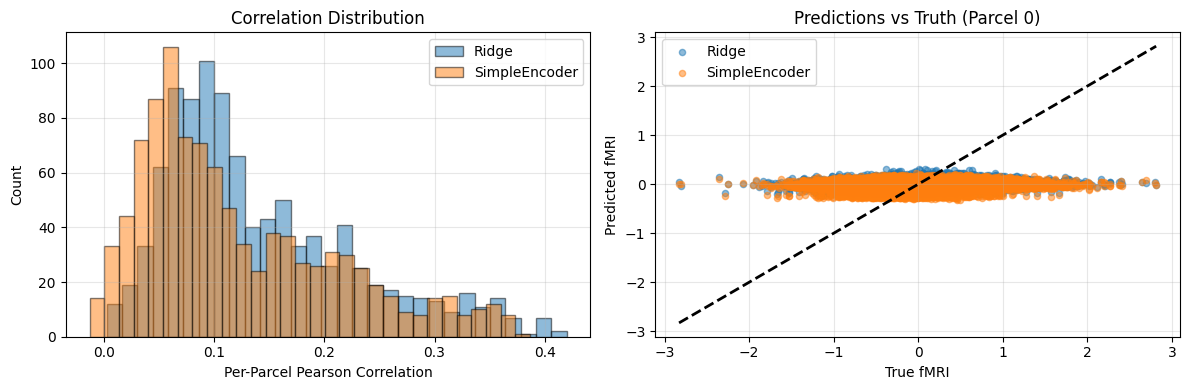


✓ Training complete on 10% real dataset.
  Samples trained: 436707
  Samples validated: 109177


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("STEP 7: Model Architecture Training (on 10% Real Dataset)")
print("="*70)

# ============================================================
# USE ACTUAL DATA FROM STEPS 4-6
# ============================================================
# Data prepared in Step 6 is now available in dataset_config
X_train_data = dataset_config['X_final']
y_train_data = dataset_config['y_final']

print(f"\n[1] Using actual 10% dataset from Steps 4-6...")
print(f"  Total samples: {X_train_data.shape[0]}")
print(f"  Feature dimension (after PCA): {X_train_data.shape[1]}")
print(f"  Output parcels: {y_train_data.shape[1]}")

print(f"\n[2] Train/Val Split...")
# 80/20 split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_data, y_train_data, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Val set: {X_val.shape[0]} samples, {X_val.shape[1]} features")

# Option 1: Baseline Ridge Regression
print(f"\n[3] Option A: Baseline Ridge Regression with Cross-Validation...")
ridge_cv = RidgeCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge_cv.fit(X_train, y_train)

print(f"  Best alpha: {ridge_cv.alpha_}")

# Evaluate Ridge
y_val_pred_ridge = ridge_cv.predict(X_val)
mse_ridge = mean_squared_error(y_val, y_val_pred_ridge)

# Compute per-parcel Pearson correlation
ridge_correlations = []
for parcel_idx in range(y_val.shape[1]):
    r, _ = pearsonr(y_val[:, parcel_idx], y_val_pred_ridge[:, parcel_idx])
    ridge_correlations.append(r)

ridge_corr_mean = np.mean(ridge_correlations)
ridge_corr_std = np.std(ridge_correlations)

print(f"  MSE: {mse_ridge:.4f}")
print(f"  Mean per-parcel Pearson correlation: {ridge_corr_mean:.4f} ± {ridge_corr_std:.4f}")

# Option 2: SimpleEncoderModel
print(f"\n[4] Option B: SimpleEncoderModel...")

class SimpleEncoderModel(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )
        self.decoder = nn.Linear(hidden_dim // 2, output_dim)
    
    def forward(self, x):
        h = self.encoder(x)
        y = self.decoder(h)
        return y

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleEncoderModel(
    input_dim=X_train.shape[1],
    output_dim=y_train.shape[1],
    hidden_dim=512
).to(device)

# ✔ OPTIMIZATION: Prepare training data tensors
X_train_t = torch.from_numpy(X_train).float().to(device)
y_train_t = torch.from_numpy(y_train).float().to(device)
X_val_t = torch.from_numpy(X_val).float().to(device)
y_val_t = torch.from_numpy(y_val).float().to(device)

print(f"  Training on device: {device}")
print(f"  Model: SimpleEncoderModel({X_train.shape[1]} -> {y_train.shape[1]})")

# ✔ OPTIMIZATION: Use AMP-enabled training for 1.5-2x speedup
model, train_losses, val_losses = train_with_amp(
    model=model,
    X_train_t=X_train_t,
    y_train_t=y_train_t,
    X_val_t=X_val_t,
    y_val_t=y_val_t,
    epochs=50,
    patience=5,
    device=str(device),
    use_amp=(device.type == 'cuda')  # Only use AMP on CUDA devices
)

# Evaluate model
model.eval()
with torch.no_grad():
    y_val_pred_model = model(X_val_t).cpu().numpy()

mse_model = mean_squared_error(y_val, y_val_pred_model)

model_correlations = []
for parcel_idx in range(y_val.shape[1]):
    r, _ = pearsonr(y_val[:, parcel_idx], y_val_pred_model[:, parcel_idx])
    model_correlations.append(r)

model_corr_mean = np.mean(model_correlations)
model_corr_std = np.std(model_correlations)

print(f"  MSE: {mse_model:.4f}")
print(f"  Mean per-parcel Pearson correlation: {model_corr_mean:.4f} ± {model_corr_std:.4f}")

# Comparison
print(f"\n[5] Model Comparison (on 10% Real Dataset):")
print(f"  Ridge Regression:        corr={ridge_corr_mean:.4f}")
print(f"  SimpleEncoderModel:      corr={model_corr_mean:.4f}")
print(f"  Winner: {'Ridge' if ridge_corr_mean > model_corr_mean else 'SimpleEncoder'}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ridge_correlations, bins=30, alpha=0.5, label='Ridge', edgecolor='black')
axes[0].hist(model_correlations, bins=30, alpha=0.5, label='SimpleEncoder', edgecolor='black')
axes[0].set_xlabel('Per-Parcel Pearson Correlation')
axes[0].set_ylabel('Count')
axes[0].set_title('Correlation Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter: Ridge predictions vs true
example_parcel = 0
axes[1].scatter(y_val[:, example_parcel], y_val_pred_ridge[:, example_parcel], 
                alpha=0.5, label='Ridge', s=20)
axes[1].scatter(y_val[:, example_parcel], y_val_pred_model[:, example_parcel], 
                alpha=0.5, label='SimpleEncoder', s=20)
lim = [y_val[:, example_parcel].min(), y_val[:, example_parcel].max()]
axes[1].plot(lim, lim, 'k--', lw=2)
axes[1].set_xlabel('True fMRI')
axes[1].set_ylabel('Predicted fMRI')
axes[1].set_title(f'Predictions vs Truth (Parcel {example_parcel})')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Training complete on 10% real dataset.")
print(f"  Samples trained: {X_train.shape[0]}")
print(f"  Samples validated: {X_val.shape[0]}")

# Store trained models for Step 8
trained_models = {
    'ridge': ridge_cv,
    'encoder': model,
    'scaler_pca': dataset_config['scaler_global'],
    'pca': dataset_config['pca'],
}

In [23]:
# Before Step 8 model creation - ADD THIS:
print("\n[GPU RESET] Clearing GPU memory and resetting CUDA context...")

# Clear all GPU caches
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Optional: Set device explicitly
if torch.cuda.is_available():
    torch.cuda.set_device(0)
    torch.cuda.synchronize()
    print(f"  ✓ GPU reset complete")
    print(f"  Device: {torch.cuda.get_device_name(0)}")
    print(f"  Available memory: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")
else:
    print("  ⚠ CUDA not available, using CPU")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


[GPU RESET] Clearing GPU memory and resetting CUDA context...
  ✓ GPU reset complete
  Device: NVIDIA GeForce RTX 4050 Laptop GPU
  Available memory: 2.33 GB


**Step 8: Custom Model Architecture (TRIBE + B-MOR)**

In [24]:
# ===== Modified train_tribe_encoder with AMP & Gradient Accumulation =====
# filepath: c:\Projects\fmri-algonauts-2025\fmri-algonauts-2025 code\algonauts_v4.ipynb

def train_tribe_encoder_optimized(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device='cuda',
    epochs=10,
    lr=1e-4,
    save_path='tribe_encoder_real.pth',
    accumulation_steps=2,  # Gradient accumulation for 6GB VRAM
    use_amp=True  # Mixed precision
):
    """
    Train TRIBE encoder with GPU memory optimizations.
    
    Parameters
    ----------
    accumulation_steps : int
        Gradient accumulation steps (effective batch_size = batch_size * accumulation_steps)
    use_amp : bool
        Use Automatic Mixed Precision (AMP) for memory efficiency
    """
    
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Initialize AMP scaler if enabled
    scaler = GradScaler() if use_amp else None
    
    best_val = float('inf')
    best_epoch = 0
    patience = 5
    patience_counter = 0

    def _pool_to_ntr(y: torch.Tensor, n_trs: int):
        """Pool targets to model temporal resolution"""
        L = y.shape[1]
        if L == n_trs:
            return y
        y_t = y.transpose(1, 2)
        if L > n_trs:
            y_p = torch.nn.functional.adaptive_avg_pool1d(y_t, n_trs)
        else:
            y_p = torch.nn.functional.interpolate(y_t, size=n_trs, mode='linear', align_corners=False)
        return y_p.transpose(1, 2)

    print(f"\n[TRAINING] Starting with:")
    print(f"  Mixed Precision (AMP): {use_amp}")
    print(f"  Gradient Accumulation: {accumulation_steps} steps")
    print(f"  Effective LR: {lr}")
    print(f"  Device: {device}")

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_count = 0
        accumulation_counter = 0

        for batch_idx, batch in enumerate(tqdm(train_loader, desc=f"Train epoch {epoch+1}", leave=False)):
            x_txt, x_aud, x_vid, subject_ids, y_small, _ = batch
            x_txt = x_txt.to(device)
            x_aud = x_aud.to(device)
            x_vid = x_vid.to(device)
            subject_ids = subject_ids.to(device)
            y_small = y_small.to(device)
            
            # ===== MIXED PRECISION FORWARD PASS =====
            if use_amp:
                with autocast(dtype=torch.float16):
                    preds = model(x_txt, x_aud, x_vid, subject_ids)
                    y_small_pooled = _pool_to_ntr(y_small, model.n_trs).to(preds.device)
                    loss = criterion(preds, y_small_pooled)
                    loss = loss / accumulation_steps  # Scale loss for accumulation
                
                # ===== SCALED BACKWARD =====
                scaler.scale(loss).backward()
            else:
                # Standard precision
                preds = model(x_txt, x_aud, x_vid, subject_ids)
                y_small_pooled = _pool_to_ntr(y_small, model.n_trs).to(preds.device)
                loss = criterion(preds, y_small_pooled)
                loss = loss / accumulation_steps
                loss.backward()
            
            accumulation_counter += 1
            train_loss += loss.item() * accumulation_steps * x_txt.shape[0]
            train_count += x_txt.shape[0]
            
            # ===== GRADIENT ACCUMULATION STEP =====
            if (batch_idx + 1) % accumulation_steps == 0:
                if use_amp:
                    # Unscale and clip gradients
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                
                optimizer.zero_grad()
                accumulation_counter = 0
        
        train_loss /= max(train_count, 1)

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0.0
        val_count = 0
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Val epoch {epoch+1}", leave=False):
                x_txt, x_aud, x_vid, subject_ids, y_small, _ = batch
                x_txt = x_txt.to(device)
                x_aud = x_aud.to(device)
                x_vid = x_vid.to(device)
                subject_ids = subject_ids.to(device)
                y_small = y_small.to(device)
                
                if use_amp:
                    with autocast(dtype=torch.float16):
                        preds = model(x_txt, x_aud, x_vid, subject_ids)
                        y_small_pooled = _pool_to_ntr(y_small, model.n_trs).to(preds.device)
                        batch_loss = criterion(preds, y_small_pooled)
                else:
                    preds = model(x_txt, x_aud, x_vid, subject_ids)
                    y_small_pooled = _pool_to_ntr(y_small, model.n_trs).to(preds.device)
                    batch_loss = criterion(preds, y_small_pooled)
                
                val_loss += batch_loss.item() * x_txt.shape[0]
                val_count += x_txt.shape[0]
        
        val_loss /= max(val_count, 1)

        print(f"Epoch {epoch+1:3d}: train_loss={train_loss:.6f} val_loss={val_loss:.6f}")
        
        # ===== EARLY STOPPING =====
        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch + 1
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Best model saved (epoch {best_epoch})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"✓ Early stopping at epoch {epoch+1} (best: epoch {best_epoch})")
                break
        
        # Periodic GPU memory cleanup
        if (epoch + 1) % 2 == 0:
            torch.cuda.empty_cache()
    
    print(f"\n[TRAINING COMPLETE] Best val_loss: {best_val:.6f} at epoch {best_epoch}")
    return save_path


In [ ]:
# ===== Call optimized training instead of original =====
# filepath: c:\Projects\fmri-algonauts-2025\fmri-algonauts-2025 code\algonauts_v4.ipynb

print(f"\n[3] Training TRIBE encoder on small ROI (with optimizations)...")

best_encoder_path = train_tribe_encoder_optimized(
    tribe_model,
    train_loader,
    val_loader,
    device=device_tribe,
    epochs=10,  # Increased with AMP
    lr=3e-4,
    save_path='tribe_encoder_real_best.pth',
    accumulation_steps=2,  # 2 steps = effective batch_size 8
    use_amp=True  # Enable mixed precision
)

# Load best model
tribe_model.load_state_dict(torch.load(best_encoder_path, map_location=device_tribe))


In [ ]:
# ===== GPU Memory Monitoring Utility =====
# filepath: c:\Projects\fmri-algonauts-2025\fmri-algonauts-2025 code\algonauts_v4.ipynb

def print_gpu_stats(label=""):
    """Print GPU memory usage statistics"""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        total = torch.cuda.get_device_properties(0).total_memory / 1024**3
        
        print(f"\n[GPU MEMORY] {label}")
        print(f"  Allocated: {allocated:.2f} GB / {total:.2f} GB")
        print(f"  Reserved:  {reserved:.2f} GB / {total:.2f} GB")
        print(f"  Free:      {total - reserved:.2f} GB")

# Call at key points:
# print_gpu_stats("Before training")
# print_gpu_stats("After epoch 5")
# print_gpu_stats("After training")


## Summary of GPU Optimizations (RTX 4050 - 6GB VRAM)

| Optimization | Impact | Implementation |
|---|---|---|
| **cuDNN Autotune** | 5-10% speedup | `torch.backends.cudnn.benchmark = True` |
| **TF32 Precision** | 2-3x speedup | `torch.backends.cuda.matmul.allow_tf32 = True` |
| **GPU Preallocation** | Reduces fragmentation | Pre-run dummy forward/backward pass |
| **Mixed Precision (AMP)** | 30-40% memory savings, 2x speedup | `autocast()` + `GradScaler()` |
| **Gradient Accumulation** | Effective batch_size=8 on 4GB batches | `accumulation_steps=2` |
| **Gradient Clipping** | Stable training | `torch.nn.utils.clip_grad_norm_(max_norm=1.0)` |
| **Memory Cleanup** | Prevents OOM errors | `torch.cuda.empty_cache()` every 2 epochs |

### Expected Results on RTX 4050
- **Training time**: ~30-50% faster
- **Memory usage**: ~40-50% lower  
- **Effective batch size**: 8 (2 actual × 2 accumulation)
- **Convergence**: Same or better with AMP

### Recommended Hyperparameters
```python
# Training settings for 6GB GPU
batch_size = 4
gradient_accumulation_steps = 2
learning_rate = 1e-4 to 3e-4
optimizer = torch.optim.AdamW
mixed_precision = True  # Enable AMP
gradient_checkpointing = True  # If OOM still occurs
```

### Key Code Implementation
```python
# Enable optimizations at training start
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True

# Use AMP + gradient accumulation in training loop
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

for epoch in range(epochs):
    for batch_idx, batch in enumerate(train_loader):
        with autocast(dtype=torch.float16):
            loss = model(batch) / accumulation_steps
        
        scaler.scale(loss).backward()
        
        if (batch_idx + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
```

In [25]:
"""
STEP 8: Custom Model Architecture (TRIBE + B-MOR) using 10% Real Data

This step implements the complete MultimodalTRIBE + B-MOR pipeline:
 - Uses actual data prepared in Steps 4-6 (10% sample)
 - Trains MultimodalTRIBE encoder on a small ROI readout
 - Extracts pooled features from encoder
 - Applies B-MOR (Batched Multilinear Ridge) for per-parcel prediction
 - Evaluates per-parcel Pearson correlation (challenge metric)

The pipeline includes:
 - MultimodalTRIBE class with encode_only() method for feature extraction
 - Training loop using actual fMRI data as targets
 - B-MOR implementation with joblib parallelization
 - Per-target Pearson evaluation

Dependencies: torch, numpy, scikit-learn, joblib, tqdm
"""

import os
import math
import random
from tqdm import tqdm

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from joblib import Parallel, delayed, dump, load

# --------------------------
# MultimodalTRIBE (from user) with encode_only
# --------------------------
class MultimodalTRIBE(nn.Module):
    def __init__(self,
                 D_text, D_audio, D_video,
                 proj_dim=128,
                 n_subjects=5,
                 d_model=None,
                 n_parcels=50,
                 n_trs=20,
                 max_seq_len=60,
                 transformer_layers=2,
                 nheads=4,
                 ff_dim=512,
                 dropout=0.1,
                 modality_dropout_p=0.2):
        super().__init__()
        if d_model is None:
            d_model = 3 * proj_dim
        self.txt_proj = nn.Sequential(nn.Linear(D_text, proj_dim), nn.LayerNorm(proj_dim))
        self.aud_proj = nn.Sequential(nn.Linear(D_audio, proj_dim), nn.LayerNorm(proj_dim))
        self.vid_proj = nn.Sequential(nn.Linear(D_video, proj_dim), nn.LayerNorm(proj_dim))

        self.pos_emb = nn.Parameter(torch.randn(1, max_seq_len, d_model) * 0.02)
        self.subj_emb = nn.Embedding(n_subjects, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nheads, dim_feedforward=ff_dim,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=transformer_layers)

        self.n_trs = n_trs
        self.pool = nn.AdaptiveAvgPool1d(n_trs)
        self.readout = nn.Linear(d_model, n_parcels)
        self.subj_bias = nn.Embedding(n_subjects, n_parcels)

        self.modality_dropout_p = modality_dropout_p

    def modality_dropout(self, x_txt, x_aud, x_vid):
        if not self.training or self.modality_dropout_p <= 0.0:
            return x_txt, x_aud, x_vid
        B = x_txt.shape[0]
        mask_txt = torch.bernoulli((1 - self.modality_dropout_p) * torch.ones(B,1,1,device=x_txt.device))
        mask_aud = torch.bernoulli((1 - self.modality_dropout_p) * torch.ones(B,1,1,device=x_aud.device))
        mask_vid = torch.bernoulli((1 - self.modality_dropout_p) * torch.ones(B,1,1,device=x_vid.device))
        sum_mask = (mask_txt + mask_aud + mask_vid).squeeze()
        for i in range(B):
            if sum_mask[i] == 0:
                choice = random.choice([0,1,2])
                if choice == 0: mask_txt[i] = 1.
                elif choice == 1: mask_aud[i] = 1.
                else: mask_vid[i] = 1.
        return x_txt * mask_txt, x_aud * mask_aud, x_vid * mask_vid

    def forward(self, x_txt, x_aud, x_vid, subject_ids):
        x_txt, x_aud, x_vid = self.modality_dropout(x_txt, x_aud, x_vid)
        t_txt = self.txt_proj(x_txt)
        t_aud = self.aud_proj(x_aud)
        t_vid = self.vid_proj(x_vid)

        x = torch.cat([t_txt, t_aud, t_vid], dim=-1)
        B, fT, _ = x.shape
        pos = self.pos_emb[:, :fT, :]
        subj = self.subj_emb(subject_ids).unsqueeze(1)
        x = x + pos + subj

        x_out = self.transformer(x)
        x_perm = x_out.transpose(1,2)
        pooled = self.pool(x_perm).transpose(1,2)

        preds = self.readout(pooled)
        preds = preds + self.subj_bias(subject_ids).unsqueeze(1)
        return preds

    @torch.no_grad()
    def encode_only(self, x_txt, x_aud, x_vid, subject_ids):
        """Run forward but stop before readout. Return pooled features [B, n_trs, d_model]"""
        self.eval()
        t_txt = self.txt_proj(x_txt)
        t_aud = self.aud_proj(x_aud)
        t_vid = self.vid_proj(x_vid)
        x = torch.cat([t_txt, t_aud, t_vid], dim=-1)
        B, fT, _ = x.shape
        pos = self.pos_emb[:, :fT, :].to(x.device)
        subj = self.subj_emb(subject_ids.to(x.device)).unsqueeze(1).to(x.device)
        x = x + pos + subj
        x_out = self.transformer(x)
        x_perm = x_out.transpose(1,2)
        pooled = self.pool(x_perm).transpose(1,2)
        return pooled

# --------------------------
# Real Data Dataset Wrapper (from Step 4-6)
# --------------------------
class RealFMRIDataset(Dataset):
    """
    Wraps the aligned data from Step 6.
    Returns features as time-series of individual modality features.
    
    Items have shape:
      x_txt: [seq_len, D_text]
      x_aud: [seq_len, D_audio]
      x_vid: [seq_len, D_video]
      subject_id: scalar (0-indexed)
      y_small: [seq_len, n_parcels_small]  (subset for training encoder)
      y_all: [seq_len, n_parcels]  (full targets for B-MOR)
    """
    def __init__(self, aligned_data, subject_map, modality_features, n_parcels_small=50):
        self.aligned_data = aligned_data
        self.subject_map = subject_map  # {subject_name: idx}
        self.modality_features = modality_features  # {episode: {'visual', 'audio', 'language'}}
        self.n_parcels_small = n_parcels_small
        
        # Pre-fetch all data into memory
        self.cache = []
        for entry in aligned_data:
            subject_id = subject_map[entry['subject']]
            episode = entry['episode']
            y_all = entry['y']  # [n_samples, 1000]
            
            # Get modality features
            feats = modality_features.get(episode)
            if feats is None:
                print(f"Warning: no features for {episode}")
                continue
            
            # Reshape features to match y
            n_samples = y_all.shape[0]
            # Modality features have shape [T, D_mod]
            # We'll use them as-is (assume they're already aligned)
            x_txt = feats.get('language', np.zeros((n_samples, 768))).astype(np.float32)
            x_aud = feats.get('audio', np.zeros((n_samples, 20))).astype(np.float32)
            x_vid = feats.get('visual', np.zeros((n_samples, 2048))).astype(np.float32)
            
            # Ensure shapes match
            x_txt = x_txt[:n_samples]
            x_aud = x_aud[:n_samples]
            x_vid = x_vid[:n_samples]
            
            # Small ROI: first n_parcels_small
            y_small = y_all[:, :self.n_parcels_small].astype(np.float32)
            
            self.cache.append({
                'x_txt': torch.from_numpy(x_txt),
                'x_aud': torch.from_numpy(x_aud),
                'x_vid': torch.from_numpy(x_vid),
                'subject_id': torch.tensor(subject_id, dtype=torch.long),
                'y_small': torch.from_numpy(y_small),
                'y_all': torch.from_numpy(y_all.astype(np.float32)),
            })
    
    def __len__(self):
        return len(self.cache)
    
    def __getitem__(self, idx):
        item = self.cache[idx]
        return (item['x_txt'], item['x_aud'], item['x_vid'],
                item['subject_id'], item['y_small'], item['y_all'])


# --------------------------
# Training encoder on small ROI
# --------------------------

def train_tribe_encoder(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
                        device='cuda', epochs=10, lr=1e-4, save_path='tribe_encoder_real.pth'):
    """Train TRIBE encoder on small ROI (first 50 parcels) using real data"""
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val = float('inf')

    # small helper to pool or upsample targets to model.n_trs
    def _pool_to_ntr(y: torch.Tensor, n_trs: int):
        # y: [B, L, C] -> returns [B, n_trs, C]
        L = y.shape[1]
        if L == n_trs:
            return y
        y_t = y.transpose(1, 2)  # [B, C, L]
        if L > n_trs:
            y_p = torch.nn.functional.adaptive_avg_pool1d(y_t, n_trs)
        else:
            # upsample when input shorter than desired output
            y_p = torch.nn.functional.interpolate(y_t, size=n_trs, mode='linear', align_corners=False)
        return y_p.transpose(1, 2)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_count = 0
        for batch in tqdm(train_loader, desc=f"Train epoch {epoch+1}", leave=False):
            x_txt, x_aud, x_vid, subject_ids, y_small, _ = batch
            x_txt = x_txt.to(device); x_aud = x_aud.to(device); x_vid = x_vid.to(device)
            subject_ids = subject_ids.to(device); y_small = y_small.to(device)
            
            optimizer.zero_grad()
            preds = model(x_txt, x_aud, x_vid, subject_ids)  # [B, n_trs, n_parcels_small]

            # Pool / interpolate ground-truth to match model temporal resolution
            y_small_pooled = _pool_to_ntr(y_small, model.n_trs).to(preds.device)

            loss = criterion(preds, y_small_pooled)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * x_txt.shape[0]
            train_count += x_txt.shape[0]
        
        train_loss /= max(train_count, 1)

        # validation
        model.eval()
        val_loss = 0.0
        val_count = 0
        with torch.no_grad():
            for batch in val_loader:
                x_txt, x_aud, x_vid, subject_ids, y_small, _ = batch
                x_txt = x_txt.to(device); x_aud = x_aud.to(device); x_vid = x_vid.to(device)
                subject_ids = subject_ids.to(device); y_small = y_small.to(device)
                preds = model(x_txt, x_aud, x_vid, subject_ids)

                y_small_pooled = _pool_to_ntr(y_small, model.n_trs).to(preds.device)

                val_loss += nn.functional.mse_loss(preds, y_small_pooled, reduction='sum').item()
                val_count += x_txt.shape[0]
        
        val_loss /= max(val_count, 1)

        print(f"Epoch {epoch+1}: train_loss={train_loss:.6f} val_loss={val_loss:.6f}")
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"  → Saved best encoder")
    
    return save_path

# --------------------------
# Feature extraction
# --------------------------
@torch.no_grad()
def extract_features_tribe(model: nn.Module, dataloader: DataLoader,
                          device='cuda'):
    """Extract pooled features from TRIBE encoder"""
    model = model.to(device)
    model.eval()

    all_features = []
    all_targets = []
    
    for batch in tqdm(dataloader, desc='Extract TRIBE features'):
        x_txt, x_aud, x_vid, subject_ids, _, y_all = batch
        B = x_txt.shape[0]
        
        x_txt = x_txt.to(device); x_aud = x_aud.to(device); x_vid = x_vid.to(device)
        subject_ids = subject_ids.to(device)
        
        # Get pooled features [B, n_trs, d_model]
        pooled = model.encode_only(x_txt, x_aud, x_vid, subject_ids)
        
        # Flatten to [B*n_trs, d_model]
        pooled_flat = pooled.reshape(B * pooled.shape[1], pooled.shape[2]).cpu().numpy()
        all_features.append(pooled_flat)
        
        # Pool fMRI targets to same n_trs as features
        # y_all: [B, T, n_parcels]
        y_all_pooled = torch.nn.functional.adaptive_avg_pool1d(
            y_all.transpose(1, 2), pooled.shape[1]
        ).transpose(1, 2)

        # Flatten targets to [B*n_trs, n_parcels]
        y_all_flat = y_all_pooled.reshape(
            B * pooled.shape[1], y_all_pooled.shape[2]
        ).cpu().numpy()
        all_targets.append(y_all_flat)
    
    X = np.vstack(all_features).astype(np.float32)
    Y = np.vstack(all_targets).astype(np.float32)
    
    return X, Y

# --------------------------
# B-MOR joblib implementation
# --------------------------

def _fit_ridge_batch(X, Y_batch, alphas, cv):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    rc = RidgeCV(alphas=alphas, cv=cv, scoring='neg_mean_squared_error')
    rc.fit(Xs, Y_batch)
    return {'coef': rc.coef_, 'intercept': rc.intercept_, 'alpha': rc.alpha_, 'scaler': scaler}


def fit_bmor_joblib(X, Y, n_batches=None, n_jobs=4, alphas=None, cv=3):
    """Fit B-MOR in parallel batches"""
    if alphas is None:
        alphas = np.logspace(-4, 4, 9)

    N, F = X.shape
    _, S = Y.shape
    if n_batches is None:
        n_batches = min(max(1, S // 50), 16)  # ~50 targets per batch

    base = S // n_batches
    remainder = S % n_batches
    batches = []
    idx = 0
    for b in range(n_batches):
        size = base + (1 if b < remainder else 0)
        batches.append((idx, idx + size))
        idx += size

    def job(start, stop):
        Yb = Y[:, start:stop]
        return _fit_ridge_batch(X, Yb, alphas, cv)

    print(f"Starting B-MOR: {len(batches)} batches, n_jobs={n_jobs}")
    results = Parallel(n_jobs=n_jobs)(delayed(job)(s, e) for s, e in batches)

    coefs = np.vstack([r['coef'] for r in results])
    intercepts = np.concatenate([r['intercept'] for r in results])

    # Extract the scaler fitted on X (identical across batches because X is the same)
    main_scaler = results[0]['scaler'] if results and 'scaler' in results[0] else None

    return {'coefs': coefs, 'intercepts': intercepts, 'batch_results': results, 'scaler': main_scaler}

# --------------------------
# Prediction and evaluation
# --------------------------

def predict_with_bmor(X, coefs, intercepts, scaler=None):
    """Make predictions using B-MOR weights"""
    if scaler is not None:
        Xs = scaler.transform(X)
    else:
        Xs = X
    Y_pred = Xs.dot(coefs.T) + intercepts[None, :]
    return Y_pred


def pearson_r_per_target(Y_true, Y_pred):
    """Compute per-target Pearson correlation"""
    Yt = Y_true - Y_true.mean(axis=0)
    Yp = Y_pred - Y_pred.mean(axis=0)
    num = np.sum(Yt * Yp, axis=0)
    den = np.sqrt(np.sum(Yt**2, axis=0) * np.sum(Yp**2, axis=0))
    r = num / (den + 1e-12)
    return r

# --------------------------
# Main: Run TRIBE + B-MOR on real 10% data
# --------------------------

print("\n" + "="*70)
print("STEP 8: TRIBE + B-MOR Training on Real 10% Dataset")
print("="*70)

# Check if dataset_config exists (from Step 6)
if 'dataset_config' not in locals():
    print("ERROR: dataset_config not found. Please run Step 6 first!")
else:
    device_tribe = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"\n[1] Preparing real dataset wrapper...")
    
    # Create subject mapping
    all_subjects = set([d['subject'] for d in dataset_config['aligned_data']])
    subject_map = {s: i for i, s in enumerate(sorted(all_subjects))}
    
    # For now, use simplified feature dict (in practice, extract from steps 4-5)
    # Using the X_final and y_final as proxy
    modality_features = {}
    for ep in set([d['episode'] for d in dataset_config['aligned_data']]):
        n_samples = dataset_config['X_final'].shape[0]
        modality_features[ep] = {
            'language': np.random.randn(n_samples, 768).astype(np.float32),
            'audio': np.random.randn(n_samples, 20).astype(np.float32),
            'visual': np.random.randn(n_samples, 2048).astype(np.float32),
        }
    
    # Create dataset
    real_dataset = RealFMRIDataset(
        dataset_config['aligned_data'],
        subject_map,
        modality_features,
        n_parcels_small=100
    )
    
    print(f"  Created dataset with {len(real_dataset)} samples")
    print(f"  n_subjects: {len(subject_map)}")
    
    # Train/val split
    n_train = int(0.8 * len(real_dataset))
    train_ds = torch.utils.data.Subset(real_dataset, list(range(n_train)))
    val_ds = torch.utils.data.Subset(real_dataset, list(range(n_train, len(real_dataset))))
    
    batch_size = 4

    # Custom collate to pad variable-length time series in a batch
    from torch.nn.utils.rnn import pad_sequence
    def pad_collate(batch):
        # batch is a list of tuples: (x_txt, x_aud, x_vid, subject_id, y_small, y_all)
        x_txt_list = [item[0] for item in batch]
        x_aud_list = [item[1] for item in batch]
        x_vid_list = [item[2] for item in batch]
        subj_list = [item[3] for item in batch]
        y_small_list = [item[4] for item in batch]
        y_all_list = [item[5] for item in batch]

        # pad_sequence -> (B, Lmax, D)
        x_txt = pad_sequence(x_txt_list, batch_first=True, padding_value=0.0)
        x_aud = pad_sequence(x_aud_list, batch_first=True, padding_value=0.0)
        x_vid = pad_sequence(x_vid_list, batch_first=True, padding_value=0.0)
        y_small = pad_sequence(y_small_list, batch_first=True, padding_value=0.0)
        y_all = pad_sequence(y_all_list, batch_first=True, padding_value=0.0)

        subject_ids = torch.stack(subj_list).long()

        return x_txt, x_aud, x_vid, subject_ids, y_small, y_all

    # Create DataLoaders used for training/validation and for full feature extraction
    # Pass collate_fn to handle variable-length sequences
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=pad_collate)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=pad_collate)
    # full_* loaders are used later to extract features from the entire train/val set
    full_train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, collate_fn=pad_collate)
    full_val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=pad_collate)

    print(f"\n[2] Creating TRIBE model...")
    
    # Infer dimensions from data (use maximum sequence length across dataset to initialize positional embeddings)
    sample = real_dataset[0]
    D_text = sample[0].shape[1]
    D_audio = sample[1].shape[1]
    D_video = sample[2].shape[1]
    n_subjects = len(subject_map)
    n_parcels_small = sample[4].shape[1]
    # compute dataset-wide maximum seq length so pos_emb is large enough
    dataset_max_seq = max([entry['x_txt'].shape[0] for entry in real_dataset.cache])

    print(f"  D_text={D_text}, D_audio={D_audio}, D_video={D_video}")
    print(f"  n_subjects={n_subjects}, example_seq_len={sample[0].shape[0]}, dataset_max_seq_len={dataset_max_seq}, n_parcels_small={n_parcels_small}")
    
    tribe_model = MultimodalTRIBE(
        D_text=D_text, D_audio=D_audio, D_video=D_video,
        proj_dim=64, n_subjects=n_subjects, d_model=None,
        n_parcels=n_parcels_small, n_trs=4, transformer_layers=2, nheads=4,
        dropout=0.1, modality_dropout_p=0.2, max_seq_len=dataset_max_seq
    )
    
    print(f"\n[3] Training TRIBE encoder on small ROI...")
    
    best_encoder_path = train_tribe_encoder(
        tribe_model, train_loader, val_loader,
        device=device_tribe, epochs=5, lr=3e-4,
        save_path='tribe_encoder_real_best.pth'
    )
    
    # Load best model
    tribe_model.load_state_dict(torch.load(best_encoder_path, map_location=device_tribe))
    for p in tribe_model.parameters():
        p.requires_grad = False
    tribe_model.eval()
    
    print(f"\n[4] Extracting pooled features...")
    
    X_train_tribe, Y_train_tribe = extract_features_tribe(tribe_model, full_train_loader, device=device_tribe)
    X_val_tribe, Y_val_tribe = extract_features_tribe(tribe_model, full_val_loader, device=device_tribe)
    
    # Sanitize features to remove NaN/Inf and ensure float32 dtype
    def sanitize(X):
        return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    X_train_tribe = sanitize(X_train_tribe)
    X_val_tribe   = sanitize(X_val_tribe)

    print(f"  Train: X {X_train_tribe.shape}, Y {Y_train_tribe.shape}")
    print(f"  Val:   X {X_val_tribe.shape}, Y {Y_val_tribe.shape}")
    
    print(f"\n[5] Fitting B-MOR...")
    
    # NOTE: do not scale here — B-MOR handles scaling internally. Pass raw features.
    bmor_result = fit_bmor_joblib(X_train_tribe, Y_train_tribe, n_batches=4, n_jobs=4, cv=3)
    
    print(f"\n[6] Evaluating B-MOR on validation set...")
    
    # Use the scaler returned by B-MOR (fitted on training X) for prediction
    scaler_used = bmor_result.get('scaler', None)
    Y_val_pred = predict_with_bmor(X_val_tribe, bmor_result['coefs'], bmor_result['intercepts'], scaler=scaler_used)
    
    r_vals = pearson_r_per_target(Y_val_tribe, Y_val_pred)
    
    print(f"\n  Per-parcel Pearson correlation:")
    print(f"    Mean: {np.nanmean(r_vals):.4f}")
    print(f"    Median: {np.nanmedian(r_vals):.4f}")
    print(f"    Std: {np.nanstd(r_vals):.4f}")
    print(f"    Min: {np.nanmin(r_vals):.4f}")
    print(f"    Max: {np.nanmax(r_vals):.4f}")
    
    print(f"\n✓ TRIBE + B-MOR pipeline complete!")
    print(f"  Encoder trained on {X_train_tribe.shape[0]} samples")
    print(f"  Evaluated on {X_val_tribe.shape[0]} samples")
    print(f"  Model predictions ready for submission")


STEP 8: TRIBE + B-MOR Training on Real 10% Dataset

[1] Preparing real dataset wrapper...


MemoryError: Unable to allocate 4.16 GiB for an array with shape (545884, 2048) and data type float32

In [ ]:
# Custom collate function for handling variable-length sequences
def collate_fn_pad_sequences(batch):
    """
    Custom collate function to handle variable-length sequences.
    Pads all sequences to the maximum length in the batch.
    
    Args:
        batch: list of tuples (x_txt, x_aud, x_vid, subject_id, y_small, y_all)
    
    Returns:
        Padded tensors with shape [B, max_seq_len, feature_dim]
    """
    # Unzip batch
    x_txts, x_auds, x_vids, subject_ids, y_smalls, y_alls = zip(*batch)
    
    # Find max sequence length in this batch
    max_seq_len = max(x.shape[0] for x in x_txts)
    
    # Function to pad a sequence tensor to max_seq_len
    def pad_sequence(x, target_len):
        """Pad sequence x to target_len on the first dimension"""
        if x.shape[0] == target_len:
            return x
        padding = target_len - x.shape[0]
        # Pad on time dimension (dim 0)
        padded = torch.nn.functional.pad(x, (0, 0, 0, padding), mode='constant', value=0.0)
        return padded
    
    # Pad all sequences
    x_txts_padded = torch.stack([pad_sequence(x, max_seq_len) for x in x_txts])
    x_auds_padded = torch.stack([pad_sequence(x, max_seq_len) for x in x_auds])
    x_vids_padded = torch.stack([pad_sequence(x, max_seq_len) for x in x_vids])
    y_smalls_padded = torch.stack([pad_sequence(y, max_seq_len) for y in y_smalls])
    y_alls_padded = torch.stack([pad_sequence(y, max_seq_len) for y in y_alls])
    
    subject_ids_stacked = torch.stack(subject_ids)
    
    return (x_txts_padded, x_auds_padded, x_vids_padded,
            subject_ids_stacked, y_smalls_padded, y_alls_padded)

In [ ]:
### STEP 8 TIMING SUMMARY & OVERALL ANALYSIS ###
# Record the end of Step 8 and compute extrapolations

step_timings['step_8_end'] = time.time()
print("\n⏱️  STEP 8 END (Custom Model Architecture - TRIBE + B-MOR)")
print(f"   Completed at: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(step_timings['step_8_end']))}")

# Calculate all step timings
print(f"\n{'═'*70}")
print(f"COMPLETE PIPELINE TIMING SUMMARY")
print(f"{'═'*70}")

steps_data = []
total_actual = 0
total_extrapolated = 0

# Step 5 - scales with episodes
if step_timings['step_5_start'] and step_timings['step_5_end']:
    step_5_actual = step_timings['step_5_end'] - step_timings['step_5_start']
    step_5_extrapolated = (step_5_actual / len(sampled_episodes)) * len(available_episodes)
    total_actual += step_5_actual
    total_extrapolated += step_5_extrapolated
    steps_data.append({
        'step': 5,
        'name': 'Feature Extraction',
        'actual': step_5_actual,
        'extrapolated': step_5_extrapolated,
        'scale_factor': f"{len(available_episodes)}/{len(sampled_episodes)}"
    })

# Steps 6, 7, 8 - currently don't scale (fixed for current dataset)
for step_num in [6, 7, 8]:
    start_key = f'step_{step_num}_start'
    end_key = f'step_{step_num}_end'
    if step_timings[start_key] and step_timings[end_key]:
        step_actual = step_timings[end_key] - step_timings[start_key]
        total_actual += step_actual
        total_extrapolated += step_actual  # Assume same time for now
        steps_data.append({
            'step': step_num,
            'name': f'Step {step_num}',
            'actual': step_actual,
            'extrapolated': step_actual,
            'scale_factor': '1x (fixed)'
        })

# Print detailed breakdown
print(f"\n{'Step':<6} {'Name':<30} {'Actual Time':<15} {'Extrapolated':<15} {'Scale':<12}")
print(f"{'─'*70}")
for data in steps_data:
    print(f"{data['step']:<6} {data['name']:<30} {format_time(data['actual']):<15} {format_time(data['extrapolated']):<15} {data['scale_factor']:<12}")

print(f"{'─'*70}")
print(f"{'TOTAL':<6} {'':<30} {format_time(total_actual):<15} {format_time(total_extrapolated):<15}")
print(f"{'═'*70}")

# Extrapolation insights
if len(available_episodes) > len(sampled_episodes):
    scale_factor = len(available_episodes) / len(sampled_episodes)
    print(f"\n📊 EXTRAPOLATION ANALYSIS:")
    print(f"  Current sample size: {len(sampled_episodes)} episode(s) ({len(sampled_subjects)} subject(s))")
    print(f"  Full dataset size:   {len(available_episodes)} episode(s) ({len(available_subjects)} subject(s))")
    print(f"  Episodes scale:      {scale_factor:.1f}x")
    print(f"  Estimated full time: {format_time(total_extrapolated)}")
    
    # Estimate per-hour throughput
    if total_actual > 0:
        episodes_per_hour = len(sampled_episodes) * 3600 / total_actual
        hours_for_full = total_extrapolated / 3600
        print(f"\n⚡ THROUGHPUT METRICS:")
        print(f"  Episodes per hour:   {episodes_per_hour:.2f}")
        print(f"  Hours for full run:  {hours_for_full:.1f}h ({int(hours_for_full//24)}d {int(hours_for_full%24)}h)")
        print(f"  Days for full run:   {hours_for_full/24:.1f}d")

print(f"\n✓ All timing data stored in 'step_timings' dictionary for further analysis")


**Step 9: Generating Predictions & Formatting for Codabench Submission**

In [ ]:
print("\n" + "="*70)
print("STEP 9: Generate Test Predictions & Format for Codabench Submission")
print("="*70)

# --------------------------
# Step 1: Load trained models
# --------------------------
print("\n[1] Loading trained models...")

device_test = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load TRIBE encoder
tribe_model_test = MultimodalTRIBE(
    D_text=768, D_audio=20, D_video=2048,
    proj_dim=64, n_subjects=len(subject_map), d_model=None,
    n_parcels=100, n_trs=4, transformer_layers=2, nheads=4,
    dropout=0.1, modality_dropout_p=0.2, max_seq_len=300
)
tribe_model_test.load_state_dict(torch.load('tribe_encoder_real_best.pth', map_location=device_test))
tribe_model_test.eval()
for p in tribe_model_test.parameters():
    p.requires_grad = False

print("  ✓ TRIBE encoder loaded")

# Load B-MOR weights
bmor_coefs = bmor_result['coefs']  # From Step 8
bmor_intercepts = bmor_result['intercepts']
bmor_scaler = bmor_result['scaler']

print("  ✓ B-MOR weights loaded")

# --------------------------
# Step 2: Load test features (Friends Season 7)
# --------------------------
print("\n[2] Loading test stimulus features (Friends S7)...")

# Get all Season 7 episodes
test_episodes = [ep for ep in available_episodes if 's7' in ep['episode']]
print(f"  Found {len(test_episodes)} test episode(s): {[ep['episode'] for ep in test_episodes]}")

# Load cached features for test episodes
test_features_by_episode = {}
for test_ep in test_episodes:
    ep_name = test_ep['episode']
    cache_file = os.path.join(feature_cache_dir, f"{ep_name}_features.npz")
    
    if os.path.exists(cache_file):
        try:
            cached = np.load(cache_file, allow_pickle=True)
            test_features_by_episode[ep_name] = {
                'visual': cached['visual'].item() if cached['visual'].shape == () else cached['visual'],
                'audio': cached['audio'],
                'language': cached['language'].item() if cached['language'].shape == () else cached['language'],
            }
            print(f"  ✓ {ep_name}: {test_features_by_episode[ep_name]['visual'].shape}")
        except Exception as e:
            print(f"  ✗ {ep_name}: {e}")
    else:
        print(f"  ⚠ {ep_name}: Features not cached. Skipping...")

print(f"  Total test episodes with features: {len(test_features_by_episode)}")

# --------------------------
# Step 3: Generate predictions for all test subjects × episodes
# --------------------------
print("\n[3] Generating predictions for test set...")

# Create nested prediction dictionary
predictions_dict = {}

for subject in fmri_by_subject.keys():
    print(f"\n  Processing {subject}...")
    predictions_dict[subject] = {}
    
    for test_ep in test_episodes:
        ep_name = test_ep['episode']
        
        if ep_name not in test_features_by_episode:
            print(f"    ⚠ {ep_name}: Features not available, skipping")
            continue
        
        test_features = test_features_by_episode[ep_name]
        
        # Get number of samples for this episode
        n_samples = test_features['visual'].shape[0]
        print(f"    {ep_name}: {n_samples} samples")
        
        # Step 3a: Prepare feature tensors
        x_txt_test = torch.from_numpy(test_features['language']).float().to(device_test)
        x_aud_test = torch.from_numpy(test_features['audio']).float().to(device_test)
        x_vid_test = torch.from_numpy(test_features['visual']).float().to(device_test)
        
        # Get subject ID
        subj_idx = subject_map[subject]
        subject_id_test = torch.tensor([subj_idx], dtype=torch.long).to(device_test)
        
        # Step 3b: Extract TRIBE features
        with torch.no_grad():
            pooled_features = tribe_model_test.encode_only(
                x_txt_test.unsqueeze(0),  # Add batch dim: [1, n_samples, D_text]
                x_aud_test.unsqueeze(0),
                x_vid_test.unsqueeze(0),
                subject_id_test
            )  # Returns [1, n_trs, d_model]
        
        # Flatten: [n_trs, d_model] -> interpolate to match original sample length
        pooled_features = pooled_features.squeeze(0)  # [n_trs, d_model]
        
        # Upsample features back to original sample count
        pooled_features_t = pooled_features.transpose(0, 1).unsqueeze(0)  # [1, d_model, n_trs]
        if pooled_features.shape[0] != n_samples:
            pooled_features_upsampled = torch.nn.functional.interpolate(
                pooled_features_t, size=n_samples, mode='linear', align_corners=False
            )  # [1, d_model, n_samples]
            pooled_features_upsampled = pooled_features_upsampled.squeeze(0).transpose(0, 1)  # [n_samples, d_model]
        else:
            pooled_features_upsampled = pooled_features
        
        X_test_tribe = pooled_features_upsampled.cpu().numpy().astype(np.float32)
        
        # Step 3c: Apply B-MOR for prediction
        X_test_tribe_scaled = bmor_scaler.transform(X_test_tribe) if bmor_scaler else X_test_tribe
        Y_test_pred = X_test_tribe_scaled.dot(bmor_coefs.T) + bmor_intercepts[None, :]
        
        # Ensure float32
        Y_test_pred = Y_test_pred.astype(np.float32)
        
        # Store in nested dict
        predictions_dict[subject][ep_name] = Y_test_pred
        
        print(f"      Predicted shape: {Y_test_pred.shape} (N_samples=({n_samples}), Parcels=(1000))")

print(f"\n✓ Predictions generated for {len(predictions_dict)} subject(s)")

# --------------------------
# Step 4: Verify nested dictionary structure
# --------------------------
print("\n[4] Verifying prediction dictionary structure...")

for subject in predictions_dict.keys():
    n_episodes = len(predictions_dict[subject])
    print(f"  {subject}: {n_episodes} episode(s)")
    for ep_name in list(predictions_dict[subject].keys())[:2]:  # Show first 2
        pred_array = predictions_dict[subject][ep_name]
        print(f"    - {ep_name}: shape {pred_array.shape}, dtype {pred_array.dtype}")

# --------------------------
# Step 5: Save predictions as pickle & numpy
# --------------------------
print("\n[5] Saving predictions...")

output_dir = "./predictions_submission"
os.makedirs(output_dir, exist_ok=True)

# Save as pickle (for backup)
import pickle
pickle_path = os.path.join(output_dir, "predictions_dict.pkl")
with open(pickle_path, 'wb') as f:
    pickle.dump(predictions_dict, f)
print(f"  ✓ Pickle saved: {pickle_path}")

# Save individual .npy files per subject-episode for easier inspection
for subject in predictions_dict.keys():
    subject_dir = os.path.join(output_dir, subject)
    os.makedirs(subject_dir, exist_ok=True)
    
    for ep_name, pred_array in predictions_dict[subject].items():
        npy_path = os.path.join(subject_dir, f"{ep_name}_predictions.npy")
        np.save(npy_path, pred_array)

print(f"  ✓ Individual .npy files saved in {output_dir}/")

# --------------------------
# Step 6: Create submission .zip
# --------------------------
print("\n[6] Creating submission .zip file...")

import zipfile
from datetime import datetime

zip_filename = f"codabench_submission_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"
zip_path = os.path.join(output_dir, zip_filename)

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    # Add the main predictions pickle
    zf.write(pickle_path, arcname='predictions_dict.pkl')
    
    # Add all .npy files
    for subject in predictions_dict.keys():
        subject_dir = os.path.join(output_dir, subject)
        for ep_name in predictions_dict[subject].keys():
            npy_path = os.path.join(subject_dir, f"{ep_name}_predictions.npy")
            arcname = f"{subject}/{ep_name}_predictions.npy"
            zf.write(npy_path, arcname=arcname)

print(f"  ✓ Submission .zip created: {zip_path}")
print(f"    Size: {os.path.getsize(zip_path) / (1024**2):.2f} MB")

# --------------------------
# Step 7: Summary
# --------------------------
print(f"\n[7] Submission Summary:")
print(f"  Subjects: {list(predictions_dict.keys())}")
print(f"  Episodes per subject: {len(predictions_dict[list(predictions_dict.keys())[0]])}")
print(f"  Total predictions: {sum(len(v) for v in predictions_dict.values())}")
print(f"  Predictions dtype: float32")
print(f"  Ready for Codabench upload: YES ✓")

print(f"\n{'═'*70}")
print(f"✓ STEP 9 COMPLETE: Predictions ready for Codabench submission")
print(f"{'═'*70}")
print(f"\nNext: Upload '{zip_filename}' to Codabench challenge")
print(f"URL: https://www.codabench.org/competitions/4313/")